In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

# Annotator competences

This notebook provides a comprehensive analysis of how annotator competences evolved over time.

## Structure:
1. **Data loading** - Load and prepare the dataset
2. **Missing data** - Analyze patterns of missing data across all three categories (intentions, reactions, consequences)
3. **Intentions** - Filtered analysis of intention annotations
4. **Reactions** - Filtered analysis of reaction annotations
5. **Consequences** - Filtered analysis of consequence annotations
6. **Comparison** - Compare all three annotation types

## 1. Data loading

In [ ]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

data_path = Path("../../data/annotated_results_complete.csv")
df = pd.read_csv(data_path)

if df['first_question_10_certainty'].dtype == 'object':
    # Convert certainty text values to numeric scale
    certainty_mapping = {
        'Niska pewność': 1,
        'Umiarkowana pewność': 2,
        'Wysoka pewność': 3,
        'Całkowita pewność': 4
    }
    df['first_question_10_certainty'] = df['first_question_10_certainty'].map(certainty_mapping)
    df['repeated_question_10_certainty'] = df['repeated_question_10_certainty'].map(certainty_mapping)

df['certainty_change'] = df['repeated_question_10_certainty'] - df['first_question_10_certainty']

print(f"Loaded {len(df)} rows with {len(df.columns)} columns")
print(f"\nAnnotator groups: {df['annotator_group'].unique().tolist()}")
print(f"Number of unique annotators: {df['annotator'].nunique()}")
print(f"\nDataset shape: {df.shape}")
print(f"\nCertainty change stats: Mean={df['certainty_change'].mean():.3f}, Non-null count={df['certainty_change'].notna().sum()}")

Loaded 750 rows with 82 columns

Annotator groups: ['komunikacja', 'rodzic', 'psycholog', 'nauczyciel', 'nastolatek']
Number of unique annotators: 25

Dataset shape: (750, 82)

Certainty change stats: Mean=0.261, Non-null count=702


## 2. Missing data

Before filtering, let's analyze how often we have missing data in each category (intentions, reactions, consequences) and understand the patterns.

In [40]:
def categorize_missing(df, first_col, repeated_col):
    categories = []
    for _, row in df.iterrows():
        first_missing = pd.isna(row[first_col]) or row[first_col] == ''
        repeated_missing = pd.isna(row[repeated_col]) or row[repeated_col] == ''
        
        if not first_missing and not repeated_missing:
            categories.append('Both present')
        elif first_missing and repeated_missing:
            categories.append('Both missing')
        elif first_missing:
            categories.append('First missing')
        else:
            categories.append('Repeated missing')
    return categories

# Categorize missing data for each type
intention_missing = categorize_missing(df, 'first_question_4_intention', 'repeated_question_4_intention')
reaction_missing = categorize_missing(df, 'first_question_9_reaction', 'repeated_question_9_reaction')
consequences_missing = categorize_missing(df, 'first_question_5_consequences', 'repeated_question_5_consequences')

print("="*80)
print("MISSING DATA PATTERNS - OVERALL")
print("="*80)
print(f"\nTotal rows: {len(df)}\n")

for name, categories in [('Intentions', intention_missing), 
                         ('Reactions', reaction_missing), 
                         ('Consequences', consequences_missing)]:
    print(f"\n{name}:")
    print("-" * 40)
    counts = pd.Series(categories).value_counts()
    for status, count in counts.items():
        pct = count / len(df) * 100
        print(f"  {status:20s}: {count:4d} ({pct:5.1f}%)")
    both_present = (pd.Series(categories) == 'Both present').sum()
    print(f"  {'Will be used in analysis':20s}: {both_present:4d} ({both_present/len(df)*100:5.1f}%)")

MISSING DATA PATTERNS - OVERALL

Total rows: 750


Intentions:
----------------------------------------
  Both present        :  644 ( 85.9%)
  First missing       :   46 (  6.1%)
  Repeated missing    :   33 (  4.4%)
  Both missing        :   27 (  3.6%)
  Will be used in analysis:  644 ( 85.9%)

Reactions:
----------------------------------------
  Both present        :  444 ( 59.2%)
  First missing       :  108 ( 14.4%)
  Repeated missing    :  102 ( 13.6%)
  Both missing        :   96 ( 12.8%)
  Will be used in analysis:  444 ( 59.2%)

Consequences:
----------------------------------------
  Both present        :  603 ( 80.4%)
  First missing       :   74 (  9.9%)
  Repeated missing    :   39 (  5.2%)
  Both missing        :   34 (  4.5%)
  Will be used in analysis:  603 ( 80.4%)


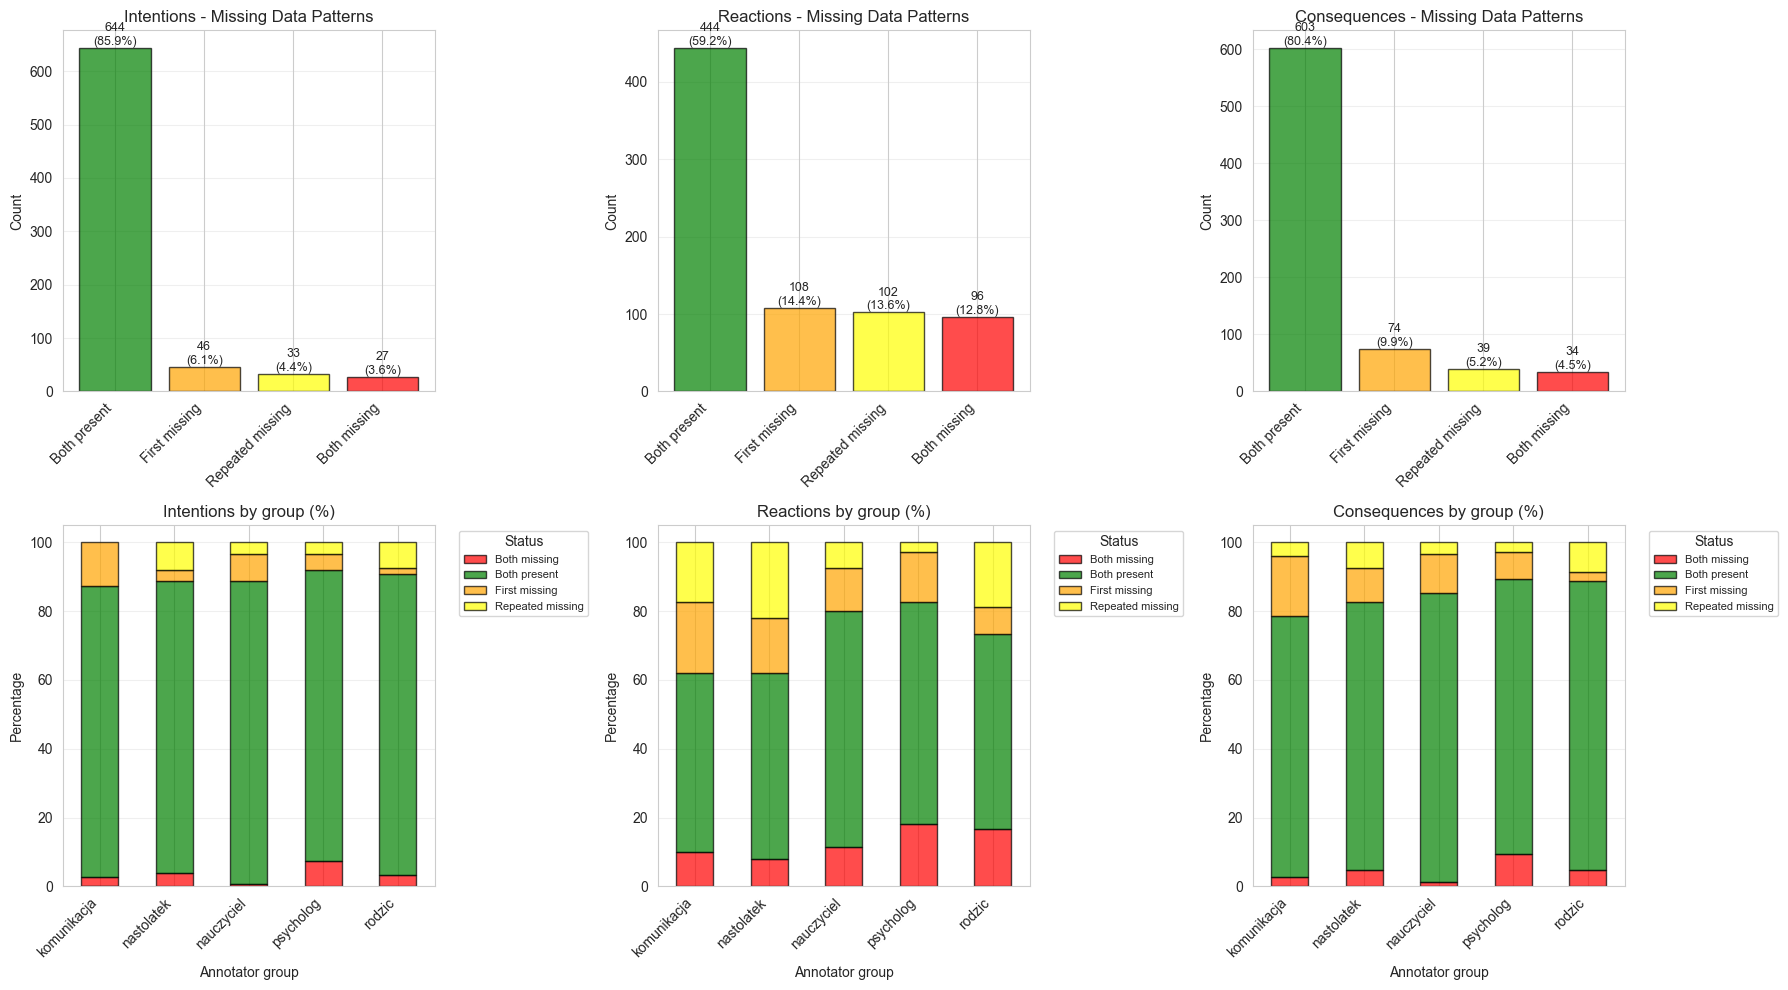

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, (name, categories) in enumerate([('Intentions', intention_missing), 
                                           ('Reactions', reaction_missing), 
                                           ('Consequences', consequences_missing)]):
    counts = pd.Series(categories).value_counts()
    colors = ['green', 'orange', 'yellow', 'red']
    axes[0, idx].bar(range(len(counts)), counts.values, 
                     color=colors[:len(counts)], edgecolor='black', alpha=0.7)
    axes[0, idx].set_xticks(range(len(counts)))
    axes[0, idx].set_xticklabels(counts.index, rotation=45, ha='right')
    axes[0, idx].set_ylabel('Count')
    axes[0, idx].set_title(f'{name} - Missing Data Patterns')
    axes[0, idx].grid(alpha=0.3, axis='y')
    
    # Add count and percentage labels
    for i, (status, val) in enumerate(counts.items()):
        axes[0, idx].text(i, val, f'{val}\n({val/len(df)*100:.1f}%)', 
                         ha='center', va='bottom', fontsize=9)

# Bottom row: By annotator group
for idx, (name, categories) in enumerate([('Intentions', intention_missing), 
                                           ('Reactions', reaction_missing), 
                                           ('Consequences', consequences_missing)]):
    df_temp = df.copy()
    df_temp['status'] = categories
    
    # Create percentage crosstab
    by_group_pct = pd.crosstab(df_temp['annotator_group'], df_temp['status'], normalize='index') * 100
    
    by_group_pct.plot(kind='bar', stacked=True, ax=axes[1, idx],
                     color=['red', 'green', 'orange', 'yellow'],
                     edgecolor='black', alpha=0.7)
    axes[1, idx].set_xlabel('Annotator group')
    axes[1, idx].set_ylabel('Percentage')
    axes[1, idx].set_title(f'{name} by group (%)')
    axes[1, idx].legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    axes[1, idx].set_xticklabels(axes[1, idx].get_xticklabels(), rotation=45, ha='right')
    axes[1, idx].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 3. Intentions

Analyze intentions, using only rows where both first and repeated intention values are present.

In [13]:
# Filter for complete intention data
intentions_df = df[
    df['first_question_4_intention'].notna() & 
    (df['first_question_4_intention'] != '') & 
    df['repeated_question_4_intention'].notna() & 
    (df['repeated_question_4_intention'] != '')
].copy()

### 3.1 Intention quality change

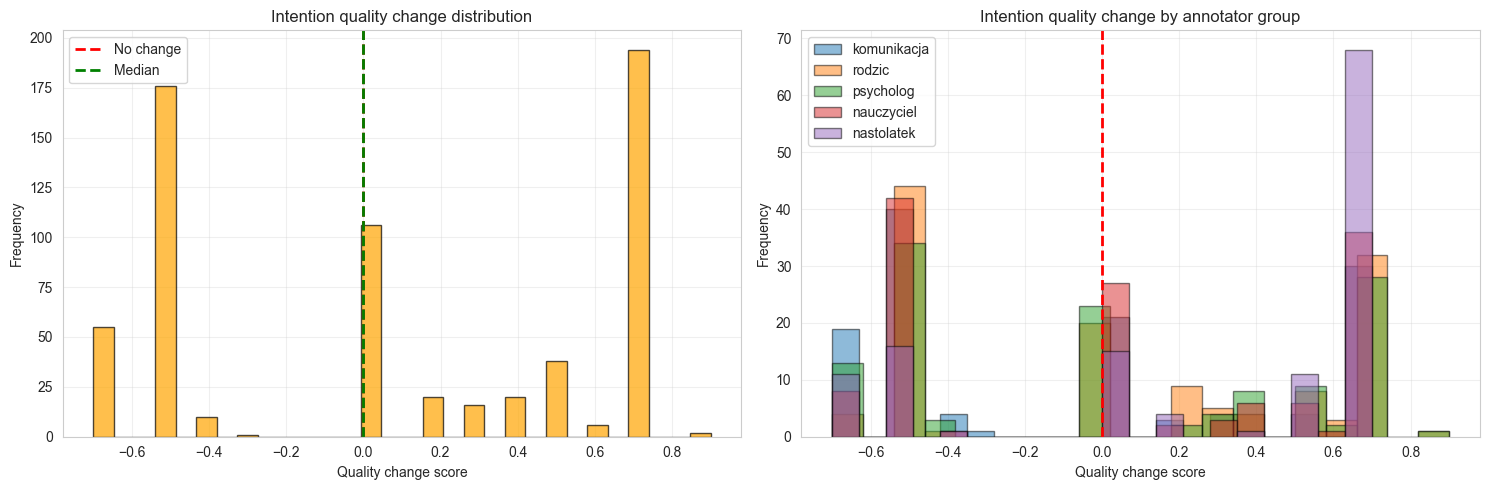

Intention quality change statistics:
count    644.000000
mean       0.071739
std        0.533636
min       -0.700000
25%       -0.500000
50%        0.000000
75%        0.700000
max        0.900000
Name: intention_evolution_assessment_quality_change, dtype: float64

Improvement rate: 46.0%
Decline rate: 37.6%
No change rate: 16.5%


In [14]:
# Overall quality change distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(intentions_df['intention_evolution_assessment_quality_change'], bins=30, edgecolor='black', alpha=0.7, color='orange')
axes[0].axvline(0, color='red', linestyle='--', linewidth=2, label='No change')
axes[0].axvline(intentions_df['intention_evolution_assessment_quality_change'].median(), 
                color='green', linestyle='--', linewidth=2, label='Median')
axes[0].set_xlabel('Quality change score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Intention quality change distribution')
axes[0].legend()
axes[0].grid(alpha=0.3)

# By annotator group (overlaid)
for group in intentions_df['annotator_group'].unique():
    group_data = intentions_df[intentions_df['annotator_group'] == group]['intention_evolution_assessment_quality_change']
    axes[1].hist(group_data, bins=20, alpha=0.5, label=f'{group}', edgecolor='black')

axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Quality change score')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Intention quality change by annotator group')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Intention quality change statistics:")
print(intentions_df['intention_evolution_assessment_quality_change'].describe())
print(f"\nImprovement rate: {(intentions_df['intention_evolution_assessment_quality_change'] > 0).mean():.1%}")
print(f"Decline rate: {(intentions_df['intention_evolution_assessment_quality_change'] < 0).mean():.1%}")
print(f"No change rate: {(intentions_df['intention_evolution_assessment_quality_change'] == 0).mean():.1%}")

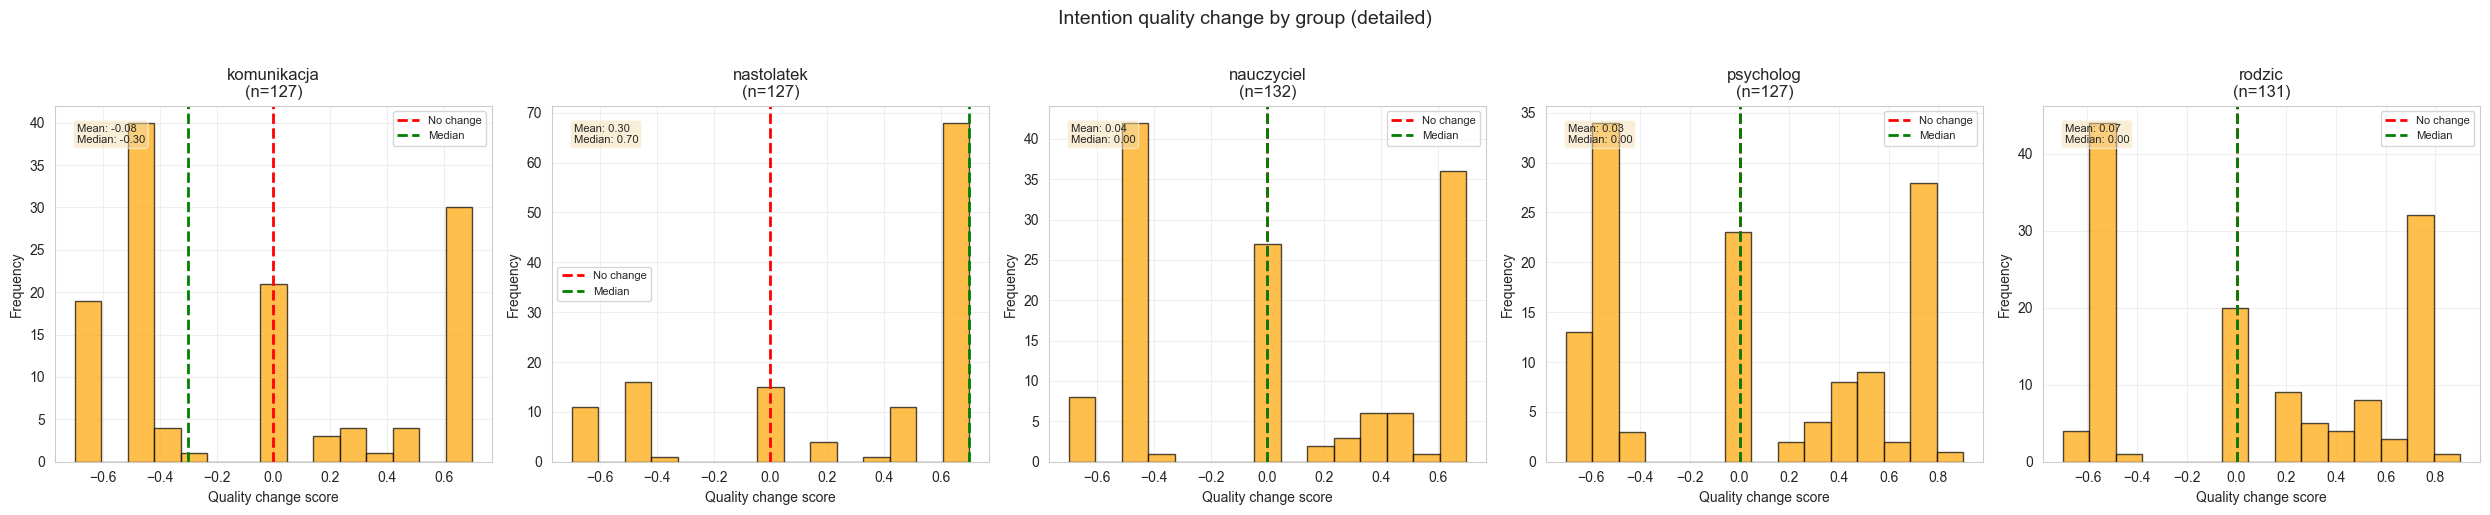

In [15]:
# per-group 
groups = sorted(intentions_df['annotator_group'].unique())
n_groups = len(groups)
fig, axes = plt.subplots(1, n_groups, figsize=(5*n_groups, 5))

if n_groups == 1:
    axes = [axes]

for idx, group in enumerate(groups):
    group_data = intentions_df[intentions_df['annotator_group'] == group]['intention_evolution_assessment_quality_change']
    
    axes[idx].hist(group_data, bins=15, edgecolor='black', alpha=0.7, color='orange')
    axes[idx].axvline(0, color='red', linestyle='--', linewidth=2, label='No change')
    axes[idx].axvline(group_data.median(), color='green', linestyle='--', linewidth=2, label='Median')
    axes[idx].set_xlabel('Quality change score')
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'{group}\n(n={len(group_data)})')
    axes[idx].legend(fontsize=8)
    axes[idx].grid(alpha=0.3)
    
    stats_text = f'Mean: {group_data.mean():.2f}\nMedian: {group_data.median():.2f}'
    axes[idx].text(0.05, 0.95, stats_text, transform=axes[idx].transAxes,
                   verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                   fontsize=8)

plt.suptitle('Intention quality change by group (detailed)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 3.2 Intention conceptual depth

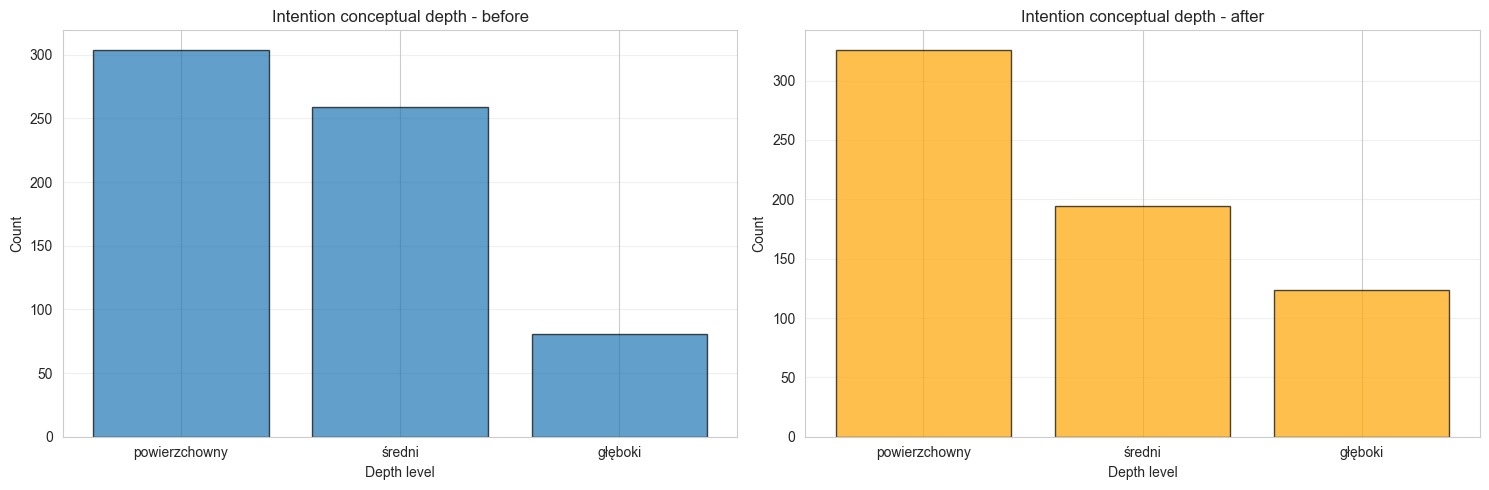

Intention depth analysis:

Before:
intention_conceptual_depth_analysis_before_level
powierzchowny    0.472050
średni           0.402174
głęboki          0.125776
Name: proportion, dtype: float64

After:
intention_conceptual_depth_analysis_after_level
powierzchowny    0.506211
średni           0.301242
głęboki          0.192547
Name: proportion, dtype: float64


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Before
before_counts = intentions_df['intention_conceptual_depth_analysis_before_level'].value_counts()
axes[0].bar(before_counts.index, before_counts.values, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Depth level')
axes[0].set_ylabel('Count')
axes[0].set_title('Intention conceptual depth - before')
axes[0].grid(alpha=0.3, axis='y')

# After
after_counts = intentions_df['intention_conceptual_depth_analysis_after_level'].value_counts()
axes[1].bar(after_counts.index, after_counts.values, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('Depth level')
axes[1].set_ylabel('Count')
axes[1].set_title('Intention conceptual depth - after')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("Intention depth analysis:")
print("\nBefore:")
print(intentions_df['intention_conceptual_depth_analysis_before_level'].value_counts(normalize=True))
print("\nAfter:")
print(intentions_df['intention_conceptual_depth_analysis_after_level'].value_counts(normalize=True))

### 3.3 Intention evolution types

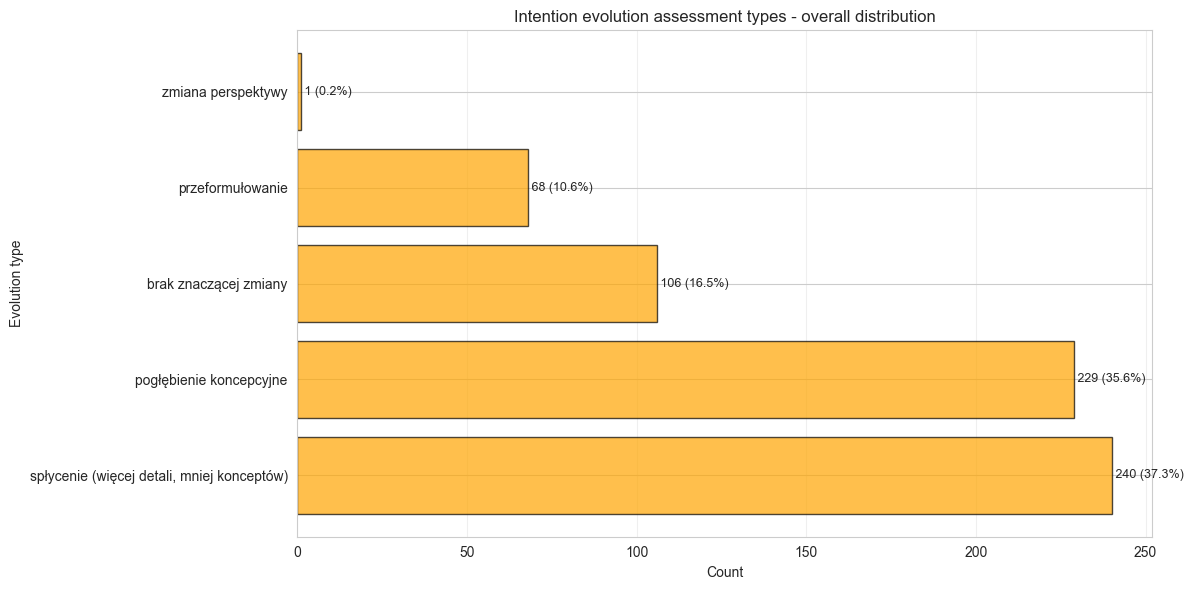

Intention evolution assessment types:
intention_evolution_assessment_type
spłycenie (więcej detali, mniej konceptów)    240
pogłębienie koncepcyjne                       229
brak znaczącej zmiany                         106
przeformułowanie                               68
zmiana perspektywy                              1
Name: count, dtype: int64

Proportions:
intention_evolution_assessment_type
spłycenie (więcej detali, mniej konceptów)    37.3%
pogłębienie koncepcyjne                       35.6%
brak znaczącej zmiany                         16.5%
przeformułowanie                              10.6%
zmiana perspektywy                             0.2%
Name: proportion, dtype: object


In [17]:
intention_type_counts = intentions_df['intention_evolution_assessment_type'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(intention_type_counts.index, intention_type_counts.values, edgecolor='black', alpha=0.7, color='orange')
ax.set_xlabel('Count')
ax.set_ylabel('Evolution type')
ax.set_title('Intention evolution assessment types - overall distribution')
ax.grid(alpha=0.3, axis='x')

for i, (idx, val) in enumerate(intention_type_counts.items()):
    ax.text(val, i, f' {val} ({val/len(intentions_df)*100:.1f}%)', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("Intention evolution assessment types:")
print(intentions_df['intention_evolution_assessment_type'].value_counts())
print("\nProportions:")
print(intentions_df['intention_evolution_assessment_type'].value_counts(normalize=True).apply(lambda x: f"{x:.1%}"))

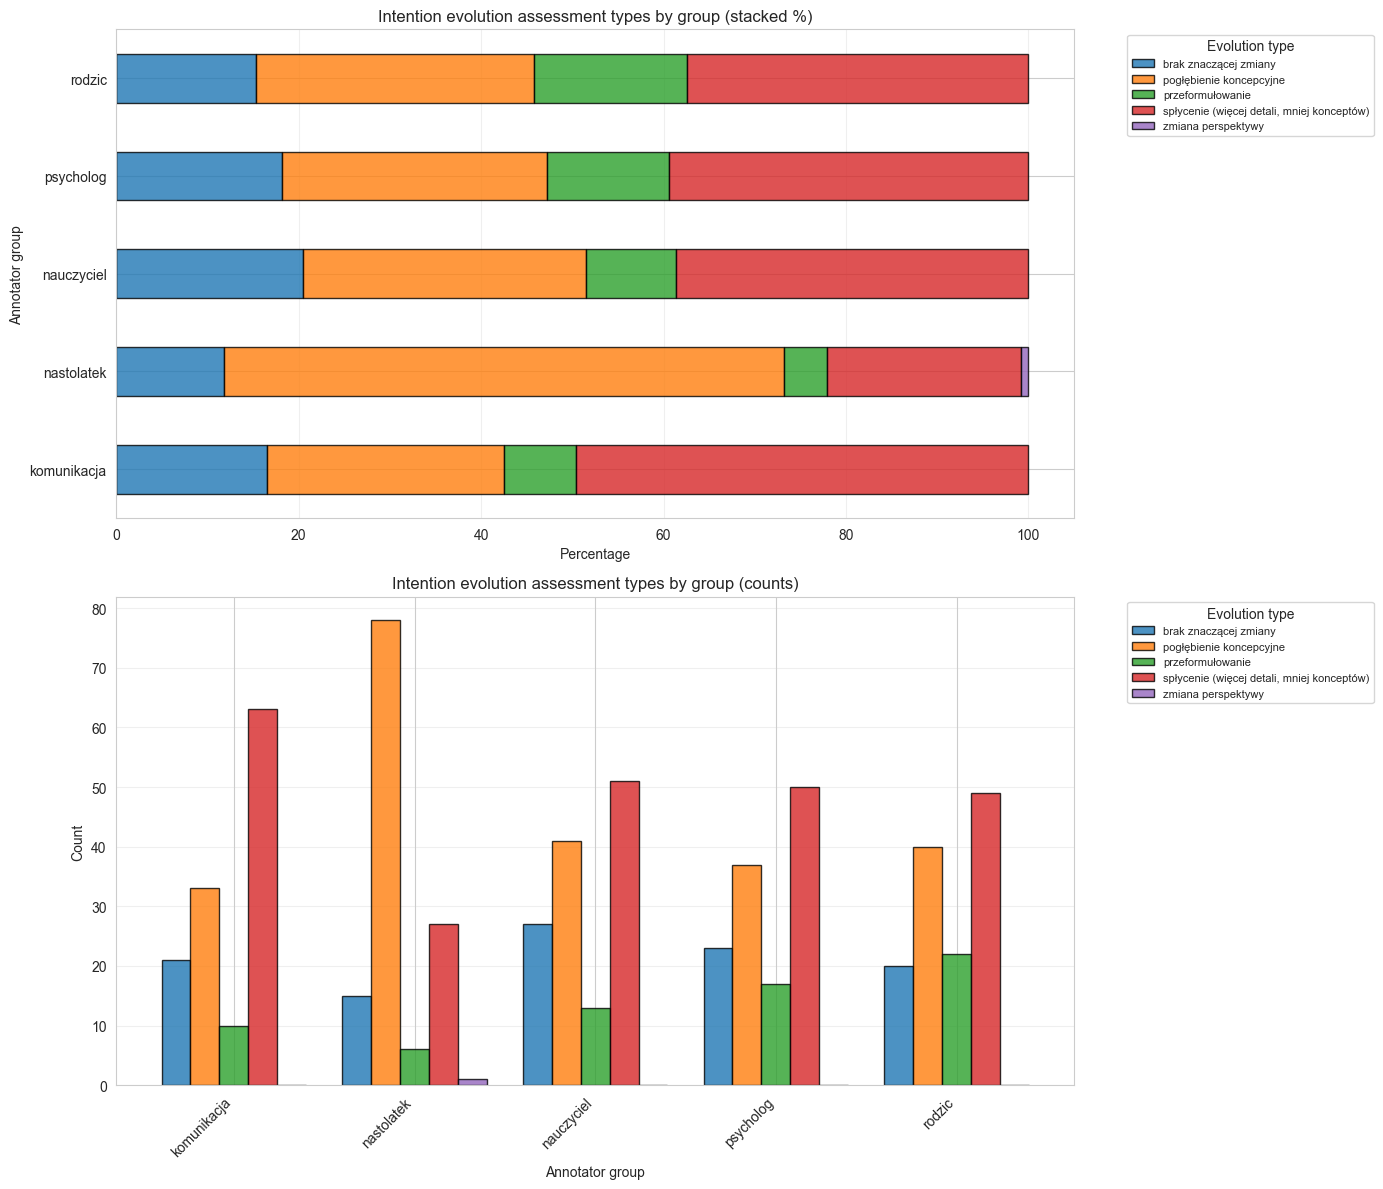

In [18]:
# Evolution types by group
intention_type_by_group = pd.crosstab(intentions_df['annotator_group'], intentions_df['intention_evolution_assessment_type'], normalize='index') * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

intention_type_by_group.plot(kind='barh', stacked=True, ax=axes[0], edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Percentage')
axes[0].set_ylabel('Annotator group')
axes[0].set_title('Intention evolution assessment types by group (stacked %)')
axes[0].legend(title='Evolution type', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[0].grid(alpha=0.3, axis='x')

intention_type_counts_by_group = pd.crosstab(intentions_df['annotator_group'], intentions_df['intention_evolution_assessment_type'])
intention_type_counts_by_group.plot(kind='bar', ax=axes[1], edgecolor='black', alpha=0.8, width=0.8)
axes[1].set_xlabel('Annotator group')
axes[1].set_ylabel('Count')
axes[1].set_title('Intention evolution assessment types by group (counts)')
axes[1].legend(title='Evolution type', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[1].grid(alpha=0.3, axis='y')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

## 4. Reactions

Analyze reactions, using only rows where both first and repeated reaction values are present.

In [19]:
reactions_df = df[
    df['first_question_9_reaction'].notna() & 
    (df['first_question_9_reaction'] != '') & 
    df['repeated_question_9_reaction'].notna() & 
    (df['repeated_question_9_reaction'] != '')
].copy()

### 4.1 Reaction quality change

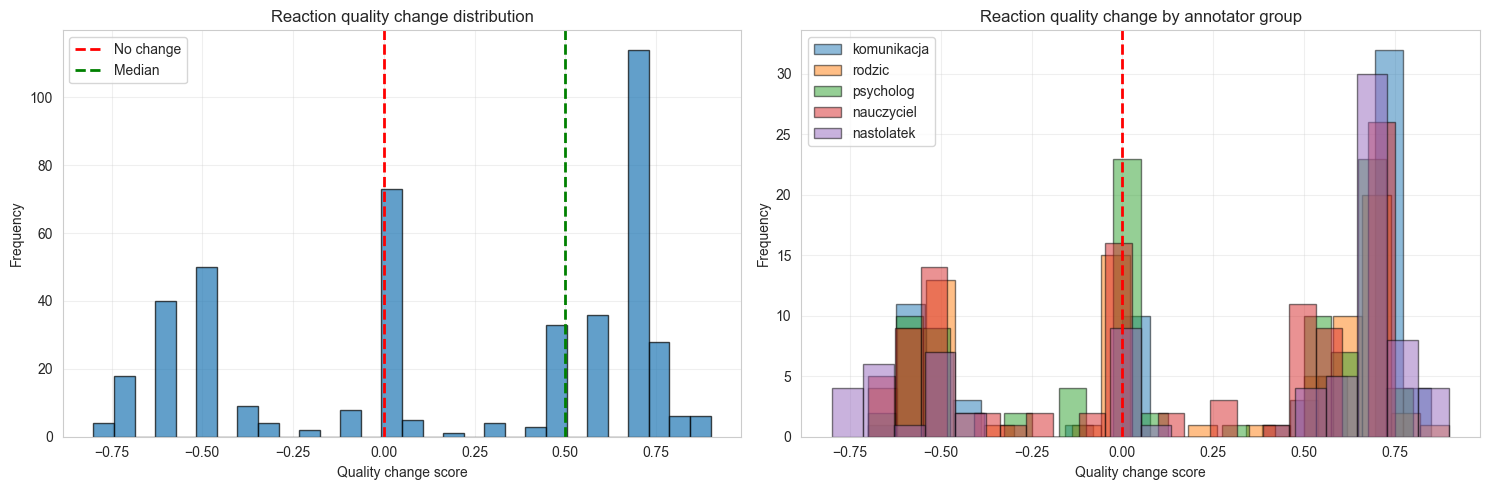

Reaction quality change statistics:
count    444.000000
mean       0.183221
std        0.536895
min       -0.800000
25%       -0.500000
50%        0.500000
75%        0.700000
max        0.900000
Name: reaction_evolution_assessment_quality_change, dtype: float64

Improvement rate: 53.2%
Decline rate: 30.4%
No change rate: 16.4%


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(reactions_df['reaction_evolution_assessment_quality_change'], bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(0, color='red', linestyle='--', linewidth=2, label='No change')
axes[0].axvline(reactions_df['reaction_evolution_assessment_quality_change'].median(), 
                color='green', linestyle='--', linewidth=2, label='Median')
axes[0].set_xlabel('Quality change score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Reaction quality change distribution')
axes[0].legend()
axes[0].grid(alpha=0.3)

for group in reactions_df['annotator_group'].unique():
    group_data = reactions_df[reactions_df['annotator_group'] == group]['reaction_evolution_assessment_quality_change']
    axes[1].hist(group_data, bins=20, alpha=0.5, label=f'{group}', edgecolor='black')

axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Quality change score')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Reaction quality change by annotator group')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Reaction quality change statistics:")
print(reactions_df['reaction_evolution_assessment_quality_change'].describe())
print(f"\nImprovement rate: {(reactions_df['reaction_evolution_assessment_quality_change'] > 0).mean():.1%}")
print(f"Decline rate: {(reactions_df['reaction_evolution_assessment_quality_change'] < 0).mean():.1%}")
print(f"No change rate: {(reactions_df['reaction_evolution_assessment_quality_change'] == 0).mean():.1%}")

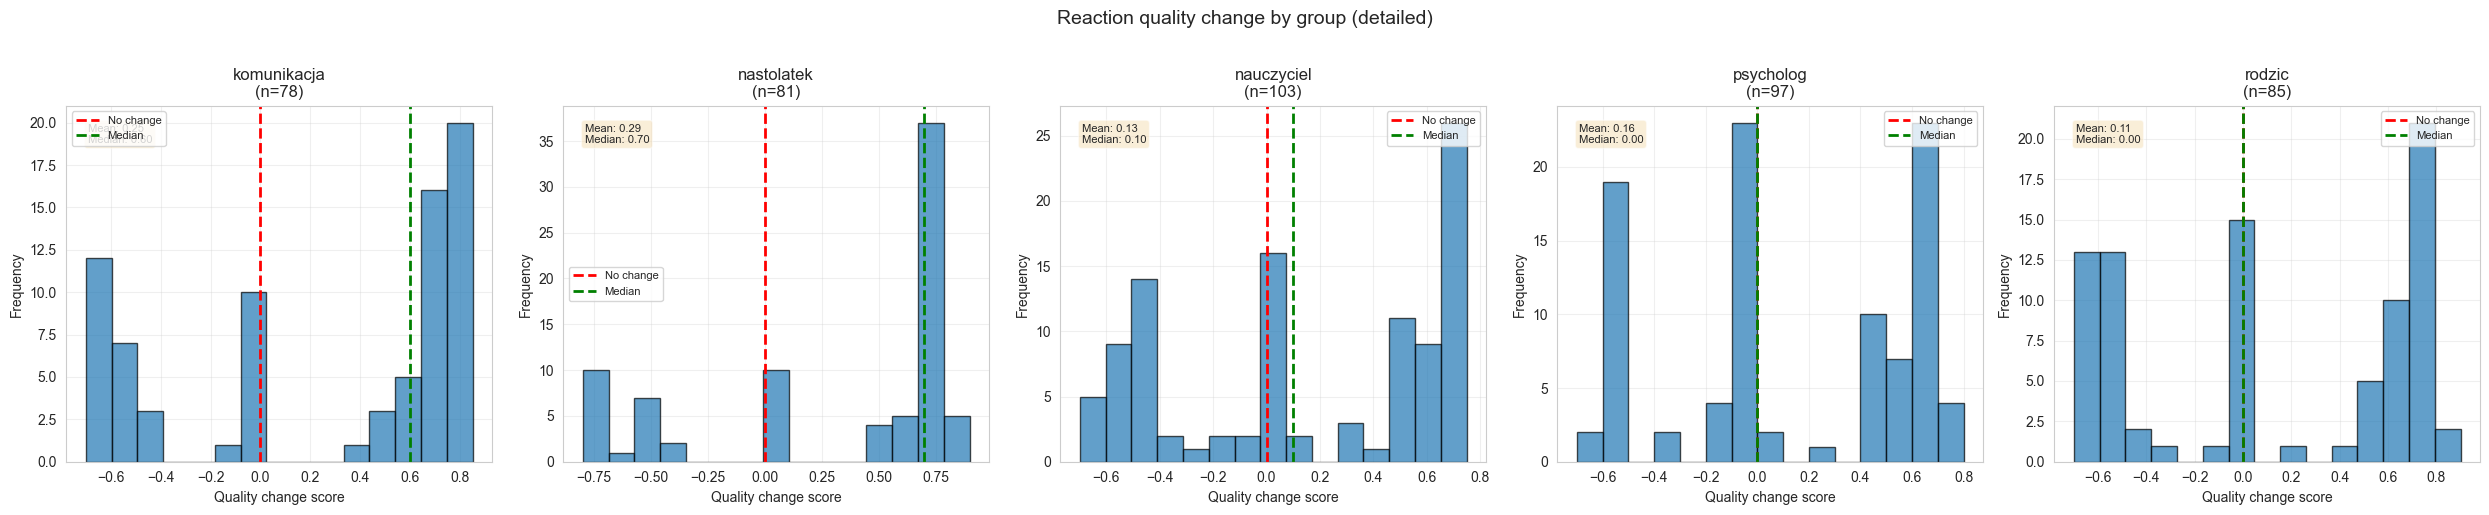

In [ ]:
# per-group 
groups = sorted(reactions_df['annotator_group'].unique())
n_groups = len(groups)
fig, axes = plt.subplots(1, n_groups, figsize=(5*n_groups, 5))

if n_groups == 1:
    axes = [axes]

for idx, group in enumerate(groups):
    group_data = reactions_df[reactions_df['annotator_group'] == group]['reaction_evolution_assessment_quality_change']
    
    axes[idx].hist(group_data, bins=15, edgecolor='black', alpha=0.7)
    axes[idx].axvline(0, color='red', linestyle='--', linewidth=2, label='No change')
    axes[idx].axvline(group_data.median(), color='green', linestyle='--', linewidth=2, label='Median')
    axes[idx].set_xlabel('Quality change score')
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'{group}\n(n={len(group_data)})')
    axes[idx].legend(fontsize=8)
    axes[idx].grid(alpha=0.3)
    
    stats_text = f'Mean: {group_data.mean():.2f}\nMedian: {group_data.median():.2f}'
    axes[idx].text(0.05, 0.95, stats_text, transform=axes[idx].transAxes,
                   verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                   fontsize=8)

plt.suptitle('Reaction quality change by group (detailed)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 4.2 Reaction psychological depth

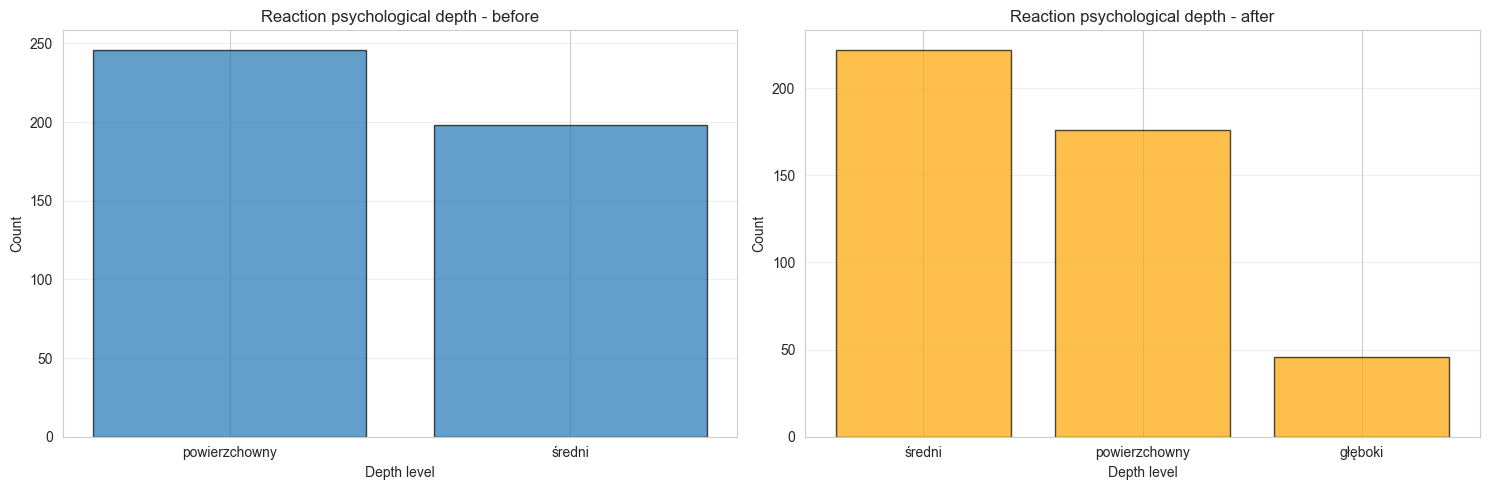

Reaction depth analysis:

Before:
reaction_psychological_depth_analysis_before_level
powierzchowny    0.554054
średni           0.445946
Name: proportion, dtype: float64

After:
reaction_psychological_depth_analysis_after_level
średni           0.500000
powierzchowny    0.396396
głęboki          0.103604
Name: proportion, dtype: float64


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Before
before_counts = reactions_df['reaction_psychological_depth_analysis_before_level'].value_counts()
axes[0].bar(before_counts.index, before_counts.values, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Depth level')
axes[0].set_ylabel('Count')
axes[0].set_title('Reaction psychological depth - before')
axes[0].grid(alpha=0.3, axis='y')

# After
after_counts = reactions_df['reaction_psychological_depth_analysis_after_level'].value_counts()
axes[1].bar(after_counts.index, after_counts.values, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('Depth level')
axes[1].set_ylabel('Count')
axes[1].set_title('Reaction psychological depth - after')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("Reaction depth analysis:")
print("\nBefore:")
print(reactions_df['reaction_psychological_depth_analysis_before_level'].value_counts(normalize=True))
print("\nAfter:")
print(reactions_df['reaction_psychological_depth_analysis_after_level'].value_counts(normalize=True))

### 4.3 Reaction evolution types

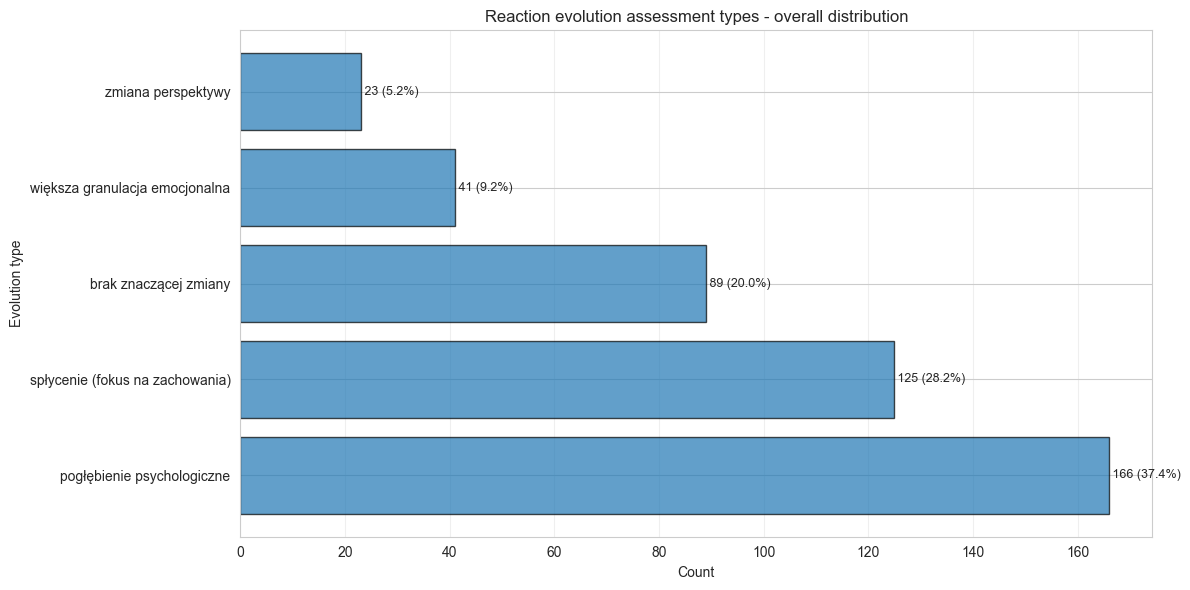

Reaction evolution assessment types:
reaction_evolution_assessment_type
pogłębienie psychologiczne         166
spłycenie (fokus na zachowania)    125
brak znaczącej zmiany               89
większa granulacja emocjonalna      41
zmiana perspektywy                  23
Name: count, dtype: int64

Proportions:
reaction_evolution_assessment_type
pogłębienie psychologiczne         37.4%
spłycenie (fokus na zachowania)    28.2%
brak znaczącej zmiany              20.0%
większa granulacja emocjonalna      9.2%
zmiana perspektywy                  5.2%
Name: proportion, dtype: object


In [23]:
reaction_type_counts = reactions_df['reaction_evolution_assessment_type'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(reaction_type_counts.index, reaction_type_counts.values, edgecolor='black', alpha=0.7)
ax.set_xlabel('Count')
ax.set_ylabel('Evolution type')
ax.set_title('Reaction evolution assessment types - overall distribution')
ax.grid(alpha=0.3, axis='x')

for i, (idx, val) in enumerate(reaction_type_counts.items()):
    ax.text(val, i, f' {val} ({val/len(reactions_df)*100:.1f}%)', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("Reaction evolution assessment types:")
print(reactions_df['reaction_evolution_assessment_type'].value_counts())
print("\nProportions:")
print(reactions_df['reaction_evolution_assessment_type'].value_counts(normalize=True).apply(lambda x: f"{x:.1%}"))

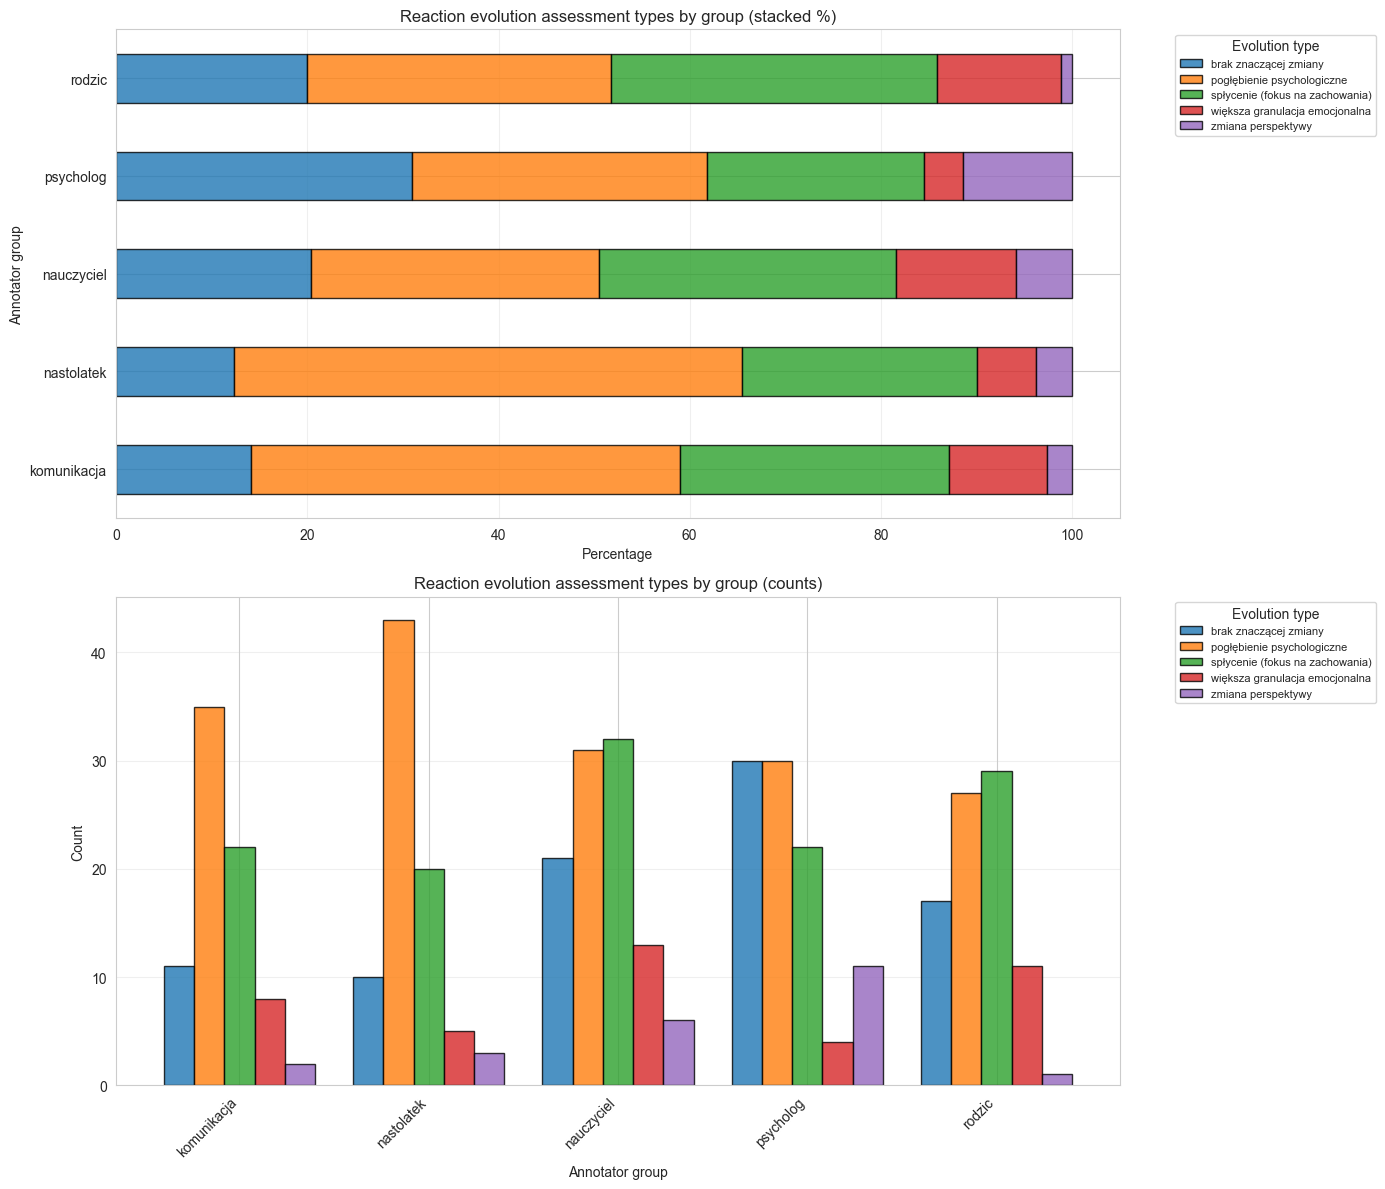

In [24]:
# by group
reaction_type_by_group = pd.crosstab(reactions_df['annotator_group'], reactions_df['reaction_evolution_assessment_type'], normalize='index') * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

reaction_type_by_group.plot(kind='barh', stacked=True, ax=axes[0], edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Percentage')
axes[0].set_ylabel('Annotator group')
axes[0].set_title('Reaction evolution assessment types by group (stacked %)')
axes[0].legend(title='Evolution type', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[0].grid(alpha=0.3, axis='x')

reaction_type_counts_by_group = pd.crosstab(reactions_df['annotator_group'], reactions_df['reaction_evolution_assessment_type'])
reaction_type_counts_by_group.plot(kind='bar', ax=axes[1], edgecolor='black', alpha=0.8, width=0.8)
axes[1].set_xlabel('Annotator group')
axes[1].set_ylabel('Count')
axes[1].set_title('Reaction evolution assessment types by group (counts)')
axes[1].legend(title='Evolution type', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[1].grid(alpha=0.3, axis='y')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

## 5. Consequences 

Consequences analysis, using only rows where both first and repeated consequence values are present.

In [25]:
consequences_df = df[
    df['first_question_5_consequences'].notna() & 
    (df['first_question_5_consequences'] != '') & 
    df['repeated_question_5_consequences'].notna() & 
    (df['repeated_question_5_consequences'] != '')
].copy()

### 5.1 Consequences quality change

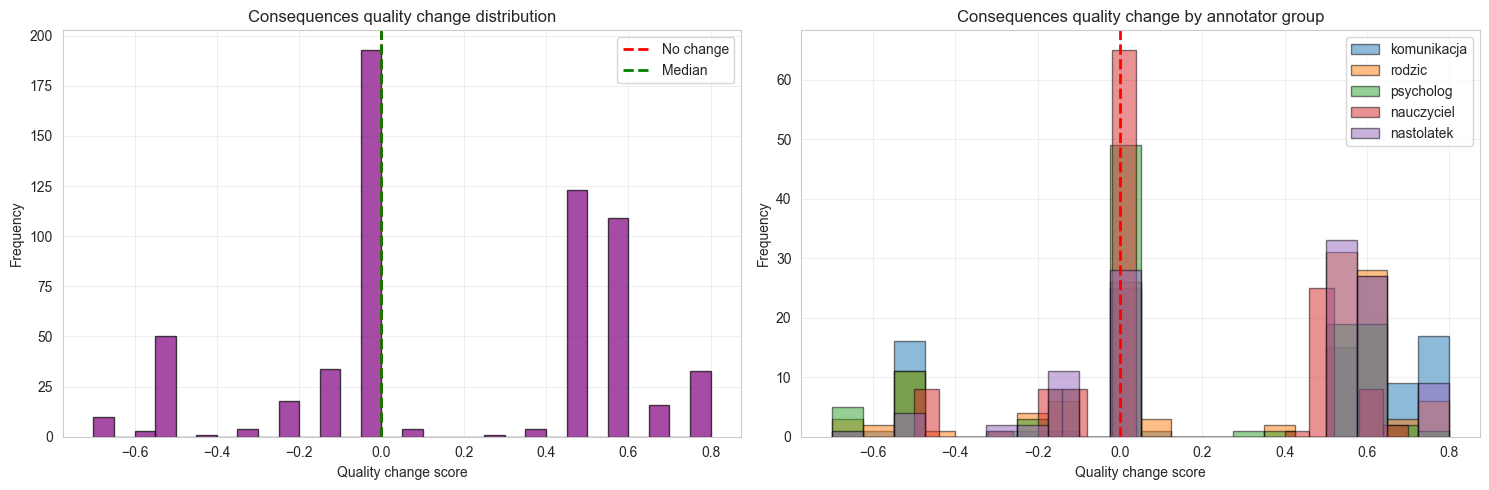

Consequences quality change statistics:
count    603.000000
mean       0.206302
std        0.395397
min       -0.700000
25%        0.000000
50%        0.000000
75%        0.600000
max        0.800000
Name: consequences_evolution_assessment_quality_change, dtype: float64

Improvement rate: 48.1%
Decline rate: 19.9%
No change rate: 32.0%


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(consequences_df['consequences_evolution_assessment_quality_change'], bins=30, edgecolor='black', alpha=0.7, color='purple')
axes[0].axvline(0, color='red', linestyle='--', linewidth=2, label='No change')
axes[0].axvline(consequences_df['consequences_evolution_assessment_quality_change'].median(), 
                color='green', linestyle='--', linewidth=2, label='Median')
axes[0].set_xlabel('Quality change score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Consequences quality change distribution')
axes[0].legend()
axes[0].grid(alpha=0.3)

for group in consequences_df['annotator_group'].unique():
    group_data = consequences_df[consequences_df['annotator_group'] == group]['consequences_evolution_assessment_quality_change']
    axes[1].hist(group_data, bins=20, alpha=0.5, label=f'{group}', edgecolor='black')

axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Quality change score')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Consequences quality change by annotator group')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Consequences quality change statistics:")
print(consequences_df['consequences_evolution_assessment_quality_change'].describe())
print(f"\nImprovement rate: {(consequences_df['consequences_evolution_assessment_quality_change'] > 0).mean():.1%}")
print(f"Decline rate: {(consequences_df['consequences_evolution_assessment_quality_change'] < 0).mean():.1%}")
print(f"No change rate: {(consequences_df['consequences_evolution_assessment_quality_change'] == 0).mean():.1%}")

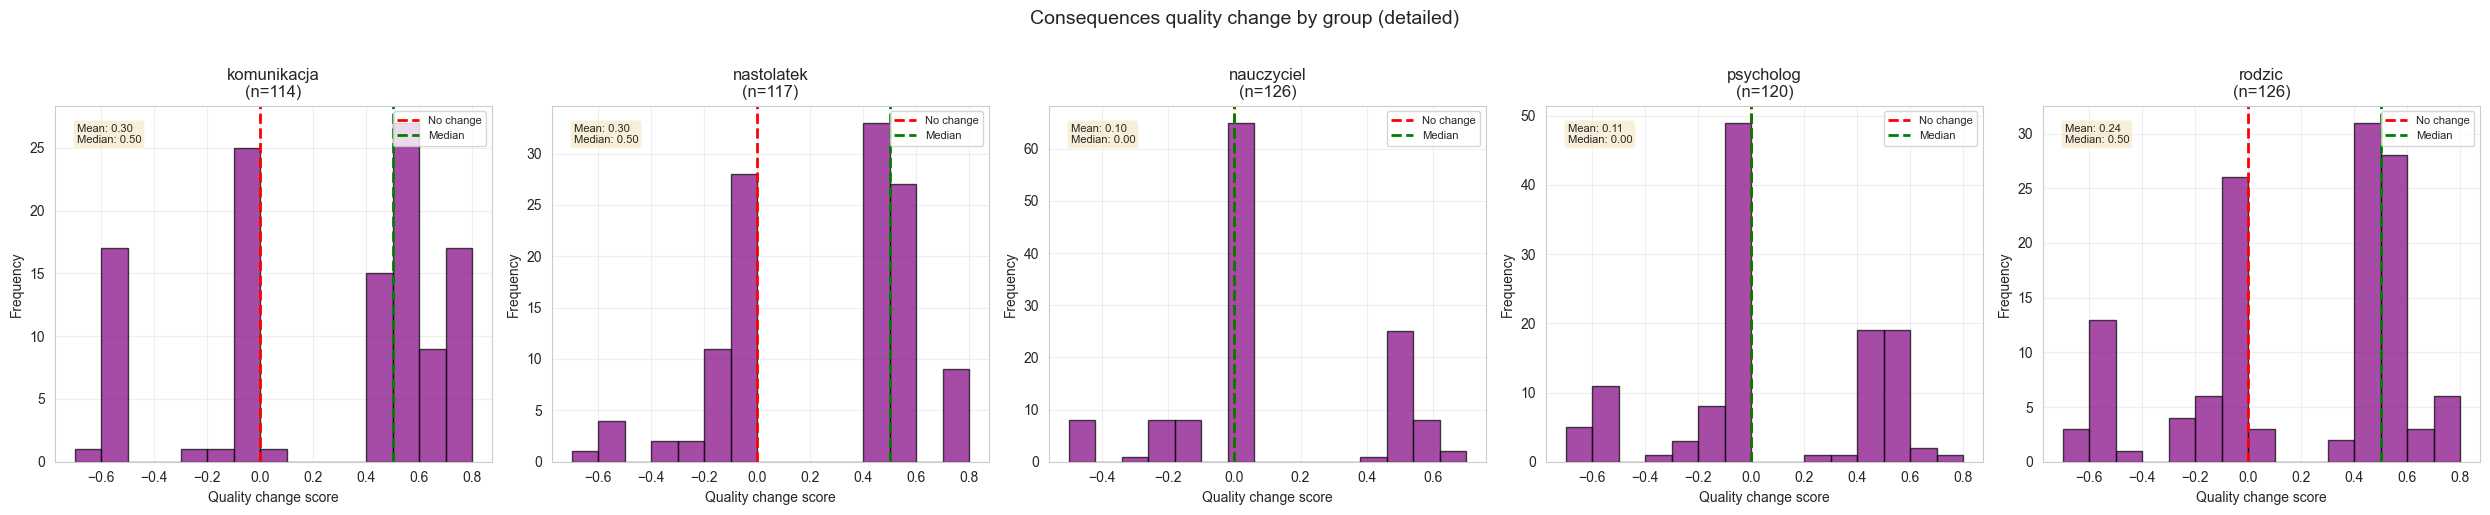

In [27]:
# per-group 
groups = sorted(consequences_df['annotator_group'].unique())
n_groups = len(groups)
fig, axes = plt.subplots(1, n_groups, figsize=(5*n_groups, 5))

if n_groups == 1:
    axes = [axes]

for idx, group in enumerate(groups):
    group_data = consequences_df[consequences_df['annotator_group'] == group]['consequences_evolution_assessment_quality_change']
    
    axes[idx].hist(group_data, bins=15, edgecolor='black', alpha=0.7, color='purple')
    axes[idx].axvline(0, color='red', linestyle='--', linewidth=2, label='No change')
    axes[idx].axvline(group_data.median(), color='green', linestyle='--', linewidth=2, label='Median')
    axes[idx].set_xlabel('Quality change score')
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'{group}\n(n={len(group_data)})')
    axes[idx].legend(fontsize=8)
    axes[idx].grid(alpha=0.3)
    
    stats_text = f'Mean: {group_data.mean():.2f}\nMedian: {group_data.median():.2f}'
    axes[idx].text(0.05, 0.95, stats_text, transform=axes[idx].transAxes,
                   verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                   fontsize=8)

plt.suptitle('Consequences quality change by group (detailed)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 5.2 Consequences conceptual depth

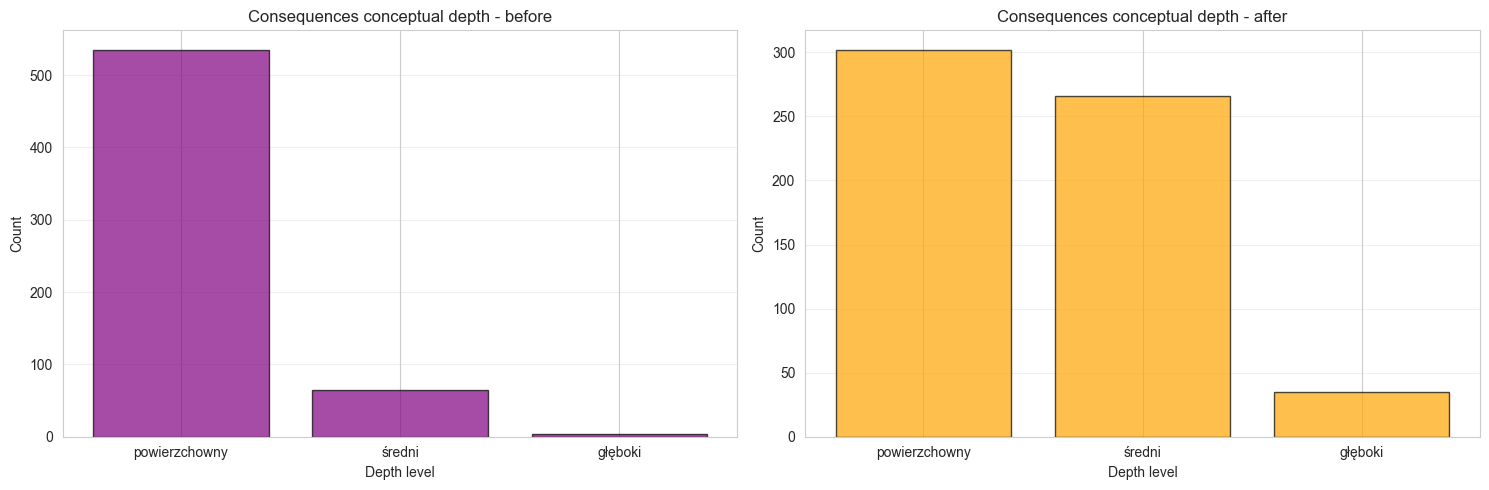

Consequences Depth Analysis:

Before:
consequences_conceptual_depth_analysis_before_level
powierzchowny    0.887231
średni           0.106136
głęboki          0.006633
Name: proportion, dtype: float64

After:
consequences_conceptual_depth_analysis_after_level
powierzchowny    0.500829
średni           0.441128
głęboki          0.058043
Name: proportion, dtype: float64


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Before
before_counts = consequences_df['consequences_conceptual_depth_analysis_before_level'].value_counts()
axes[0].bar(before_counts.index, before_counts.values, edgecolor='black', alpha=0.7, color='purple')
axes[0].set_xlabel('Depth level')
axes[0].set_ylabel('Count')
axes[0].set_title('Consequences conceptual depth - before')
axes[0].grid(alpha=0.3, axis='y')

# After
after_counts = consequences_df['consequences_conceptual_depth_analysis_after_level'].value_counts()
axes[1].bar(after_counts.index, after_counts.values, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('Depth level')
axes[1].set_ylabel('Count')
axes[1].set_title('Consequences conceptual depth - after')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("Consequences Depth Analysis:")
print("\nBefore:")
print(consequences_df['consequences_conceptual_depth_analysis_before_level'].value_counts(normalize=True))
print("\nAfter:")
print(consequences_df['consequences_conceptual_depth_analysis_after_level'].value_counts(normalize=True))

### 5.4 Consequences evolution types

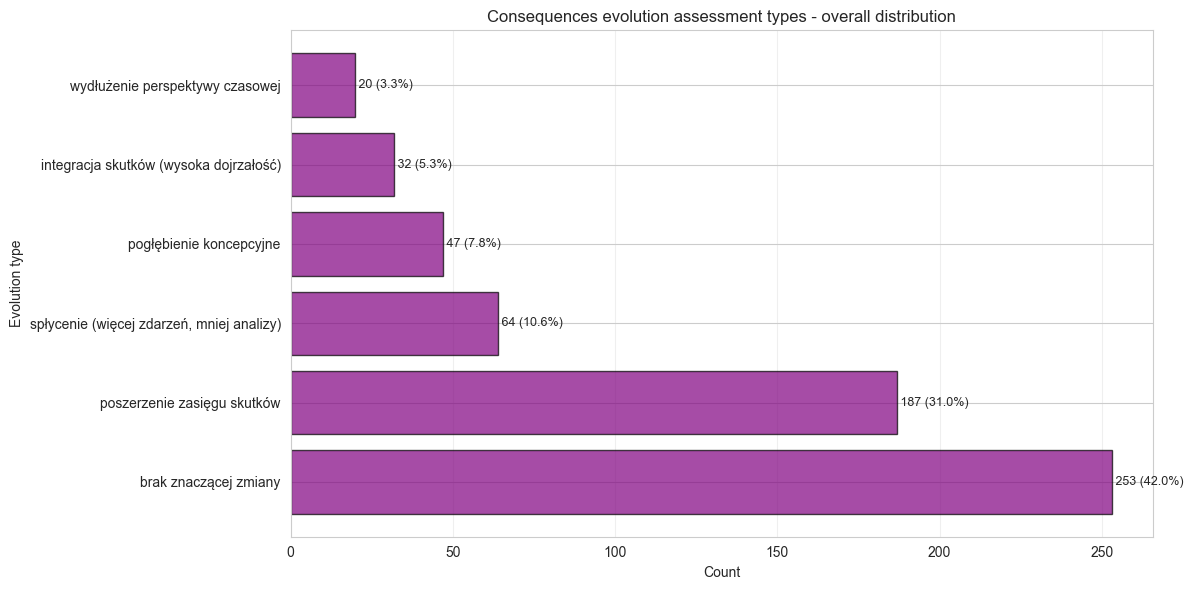

Consequences evolution assessment types:
consequences_evolution_assessment_type
brak znaczącej zmiany                        253
poszerzenie zasięgu skutków                  187
spłycenie (więcej zdarzeń, mniej analizy)     64
pogłębienie koncepcyjne                       47
integracja skutków (wysoka dojrzałość)        32
wydłużenie perspektywy czasowej               20
Name: count, dtype: int64

Proportions:
consequences_evolution_assessment_type
brak znaczącej zmiany                        42.0%
poszerzenie zasięgu skutków                  31.0%
spłycenie (więcej zdarzeń, mniej analizy)    10.6%
pogłębienie koncepcyjne                       7.8%
integracja skutków (wysoka dojrzałość)        5.3%
wydłużenie perspektywy czasowej               3.3%
Name: proportion, dtype: object


In [30]:
# Evolution type distribution
consequences_type_counts = consequences_df['consequences_evolution_assessment_type'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(consequences_type_counts.index, consequences_type_counts.values, edgecolor='black', alpha=0.7, color='purple')
ax.set_xlabel('Count')
ax.set_ylabel('Evolution type')
ax.set_title('Consequences evolution assessment types - overall distribution')
ax.grid(alpha=0.3, axis='x')

for i, (idx, val) in enumerate(consequences_type_counts.items()):
    ax.text(val, i, f' {val} ({val/len(consequences_df)*100:.1f}%)', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("Consequences evolution assessment types:")
print(consequences_df['consequences_evolution_assessment_type'].value_counts())
print("\nProportions:")
print(consequences_df['consequences_evolution_assessment_type'].value_counts(normalize=True).apply(lambda x: f"{x:.1%}"))

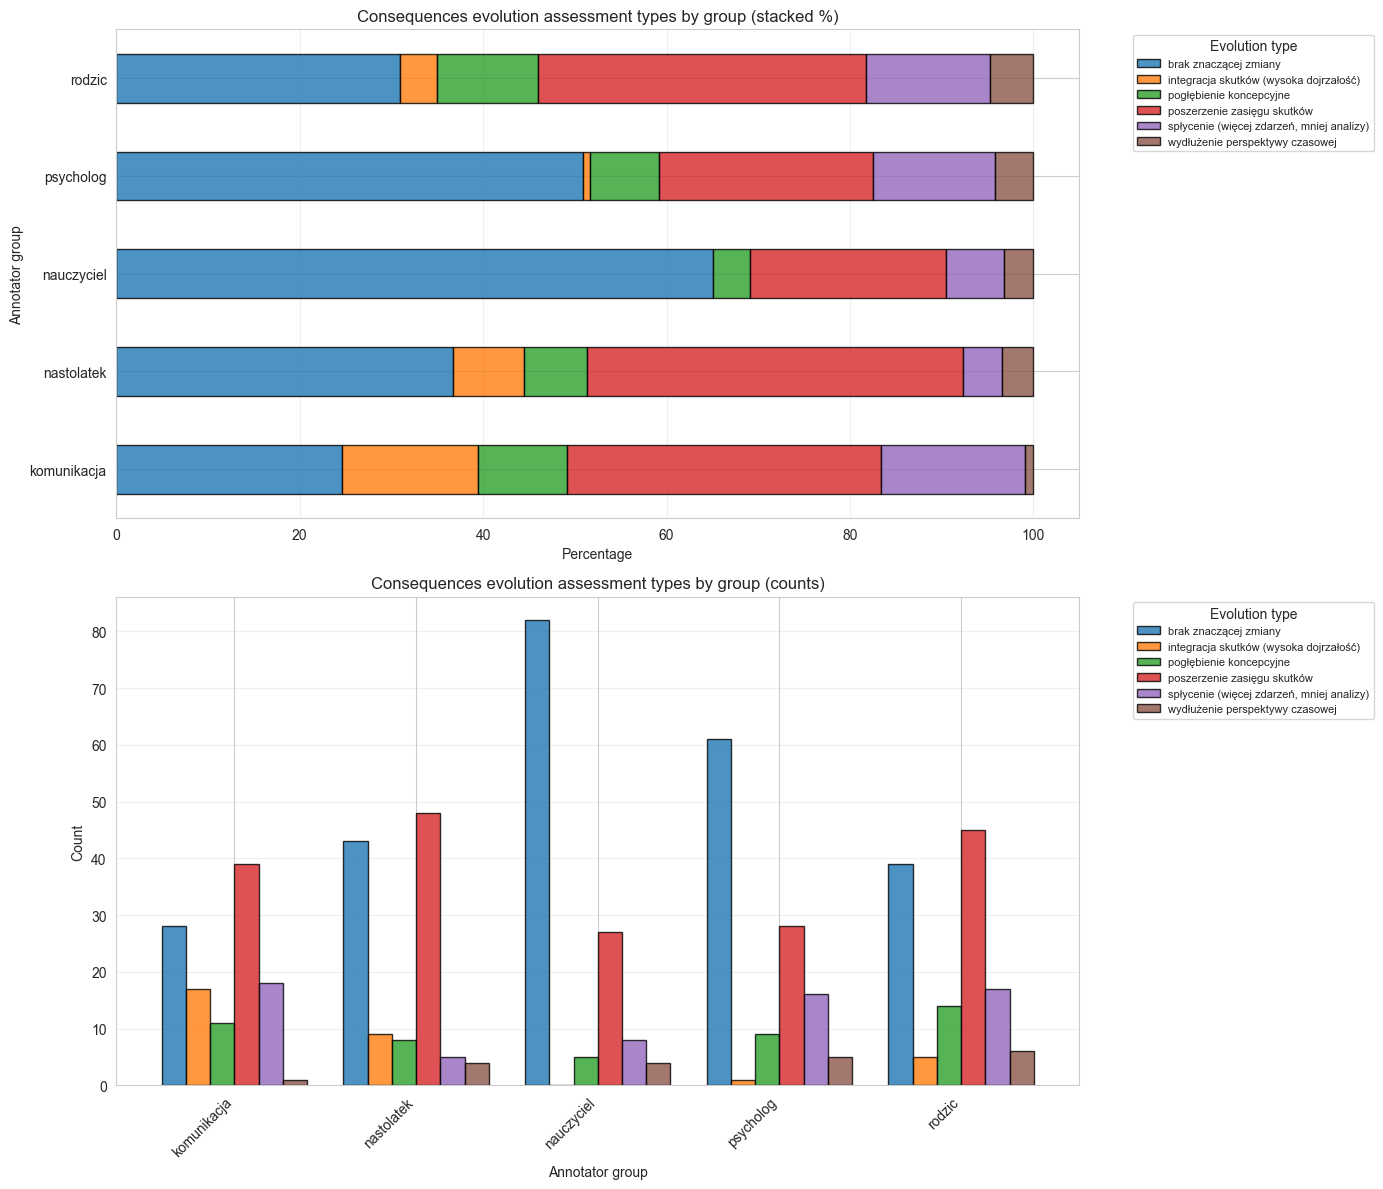

In [31]:
# by group
consequences_type_by_group = pd.crosstab(consequences_df['annotator_group'], consequences_df['consequences_evolution_assessment_type'], normalize='index') * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

consequences_type_by_group.plot(kind='barh', stacked=True, ax=axes[0], edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Percentage')
axes[0].set_ylabel('Annotator group')
axes[0].set_title('Consequences evolution assessment types by group (stacked %)')
axes[0].legend(title='Evolution type', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[0].grid(alpha=0.3, axis='x')

consequences_type_counts_by_group = pd.crosstab(consequences_df['annotator_group'], consequences_df['consequences_evolution_assessment_type'])
consequences_type_counts_by_group.plot(kind='bar', ax=axes[1], edgecolor='black', alpha=0.8, width=0.8)
axes[1].set_xlabel('Annotator group')
axes[1].set_ylabel('Count')
axes[1].set_title('Consequences evolution assessment types by group (counts)')
axes[1].legend(title='Evolution type', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[1].grid(alpha=0.3, axis='y')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

## 6. Comparison

Now let's compare all three annotation types: intentions, reactions, and consequences.

### 6.1 Quality change comparison

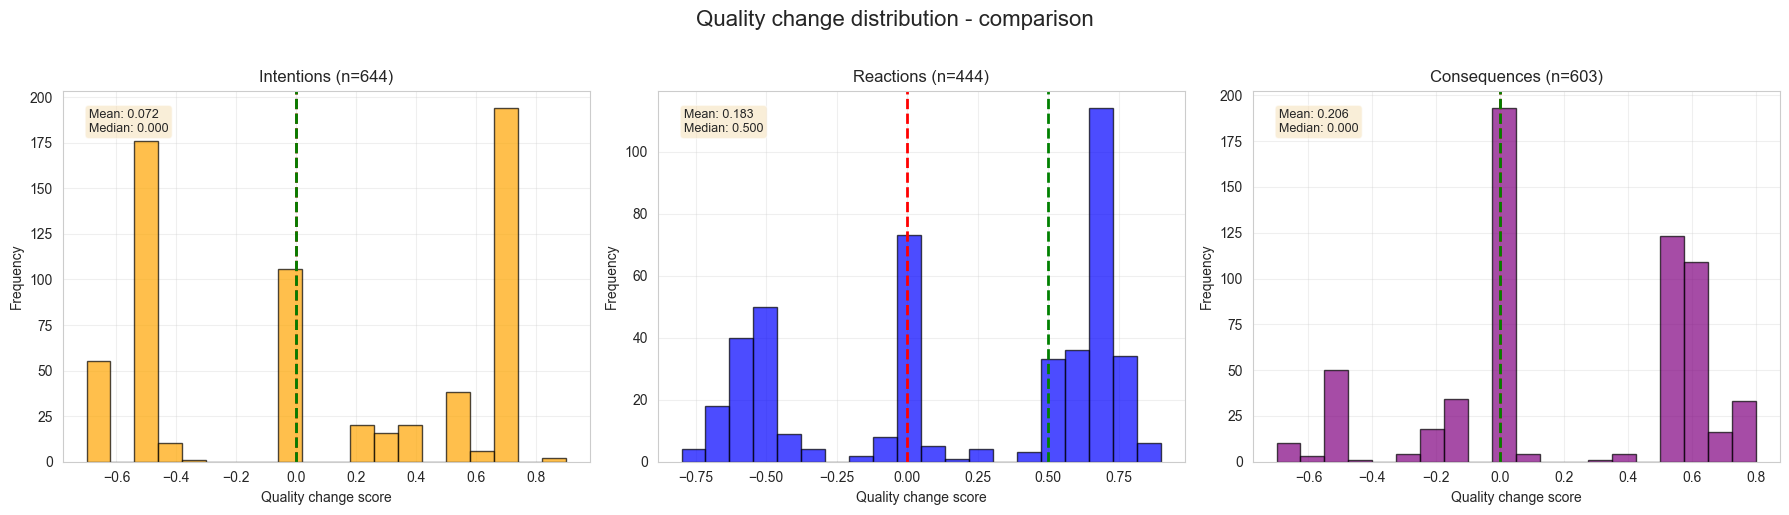

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Intentions
axes[0].hist(intentions_df['intention_evolution_assessment_quality_change'], bins=20, 
             edgecolor='black', alpha=0.7, color='orange')
axes[0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0].axvline(intentions_df['intention_evolution_assessment_quality_change'].median(), 
                color='green', linestyle='--', linewidth=2)
axes[0].set_xlabel('Quality change score')
axes[0].set_ylabel('Frequency')
axes[0].set_title(f'Intentions (n={len(intentions_df)})')
axes[0].grid(alpha=0.3)
stats_text = f'Mean: {intentions_df["intention_evolution_assessment_quality_change"].mean():.3f}\nMedian: {intentions_df["intention_evolution_assessment_quality_change"].median():.3f}'
axes[0].text(0.05, 0.95, stats_text, transform=axes[0].transAxes,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5), fontsize=9)

# Reactions
axes[1].hist(reactions_df['reaction_evolution_assessment_quality_change'], bins=20, 
             edgecolor='black', alpha=0.7, color='blue')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].axvline(reactions_df['reaction_evolution_assessment_quality_change'].median(), 
                color='green', linestyle='--', linewidth=2)
axes[1].set_xlabel('Quality change score')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Reactions (n={len(reactions_df)})')
axes[1].grid(alpha=0.3)
stats_text = f'Mean: {reactions_df["reaction_evolution_assessment_quality_change"].mean():.3f}\nMedian: {reactions_df["reaction_evolution_assessment_quality_change"].median():.3f}'
axes[1].text(0.05, 0.95, stats_text, transform=axes[1].transAxes,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5), fontsize=9)

# Consequences
axes[2].hist(consequences_df['consequences_evolution_assessment_quality_change'], bins=20, 
             edgecolor='black', alpha=0.7, color='purple')
axes[2].axvline(0, color='red', linestyle='--', linewidth=2)
axes[2].axvline(consequences_df['consequences_evolution_assessment_quality_change'].median(), 
                color='green', linestyle='--', linewidth=2)
axes[2].set_xlabel('Quality change score')
axes[2].set_ylabel('Frequency')
axes[2].set_title(f'Consequences (n={len(consequences_df)})')
axes[2].grid(alpha=0.3)
stats_text = f'Mean: {consequences_df["consequences_evolution_assessment_quality_change"].mean():.3f}\nMedian: {consequences_df["consequences_evolution_assessment_quality_change"].median():.3f}'
axes[2].text(0.05, 0.95, stats_text, transform=axes[2].transAxes,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5), fontsize=9)

plt.suptitle('Quality change distribution - comparison', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [34]:
# Statistical summary comparison
print("="*80)
print("QUALITY CHANGE STATISTICS - COMPARISON")
print("="*80)

comparison_data = {
    'Metric': ['Dataset size', 'Mean quality change', 'Median quality change', 'Std deviation',
               'Improvement rate', 'Decline rate', 'No change rate'],
    'Intentions': [
        f"{len(intentions_df)}",
        f"{intentions_df['intention_evolution_assessment_quality_change'].mean():.3f}",
        f"{intentions_df['intention_evolution_assessment_quality_change'].median():.3f}",
        f"{intentions_df['intention_evolution_assessment_quality_change'].std():.3f}",
        f"{(intentions_df['intention_evolution_assessment_quality_change'] > 0).mean():.1%}",
        f"{(intentions_df['intention_evolution_assessment_quality_change'] < 0).mean():.1%}",
        f"{(intentions_df['intention_evolution_assessment_quality_change'] == 0).mean():.1%}"
    ],
    'Reactions': [
        f"{len(reactions_df)}",
        f"{reactions_df['reaction_evolution_assessment_quality_change'].mean():.3f}",
        f"{reactions_df['reaction_evolution_assessment_quality_change'].median():.3f}",
        f"{reactions_df['reaction_evolution_assessment_quality_change'].std():.3f}",
        f"{(reactions_df['reaction_evolution_assessment_quality_change'] > 0).mean():.1%}",
        f"{(reactions_df['reaction_evolution_assessment_quality_change'] < 0).mean():.1%}",
        f"{(reactions_df['reaction_evolution_assessment_quality_change'] == 0).mean():.1%}"
    ],
    'Consequences': [
        f"{len(consequences_df)}",
        f"{consequences_df['consequences_evolution_assessment_quality_change'].mean():.3f}",
        f"{consequences_df['consequences_evolution_assessment_quality_change'].median():.3f}",
        f"{consequences_df['consequences_evolution_assessment_quality_change'].std():.3f}",
        f"{(consequences_df['consequences_evolution_assessment_quality_change'] > 0).mean():.1%}",
        f"{(consequences_df['consequences_evolution_assessment_quality_change'] < 0).mean():.1%}",
        f"{(consequences_df['consequences_evolution_assessment_quality_change'] == 0).mean():.1%}"
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))
print("="*80)

QUALITY CHANGE STATISTICS - COMPARISON
               Metric Intentions Reactions Consequences
         Dataset size        644       444          603
  Mean quality change      0.072     0.183        0.206
Median quality change      0.000     0.500        0.000
        Std deviation      0.534     0.537        0.395
     Improvement rate      46.0%     53.2%        48.1%
         Decline rate      37.6%     30.4%        19.9%
       No change rate      16.5%     16.4%        32.0%


### 6.2 Quality change by annotator group 

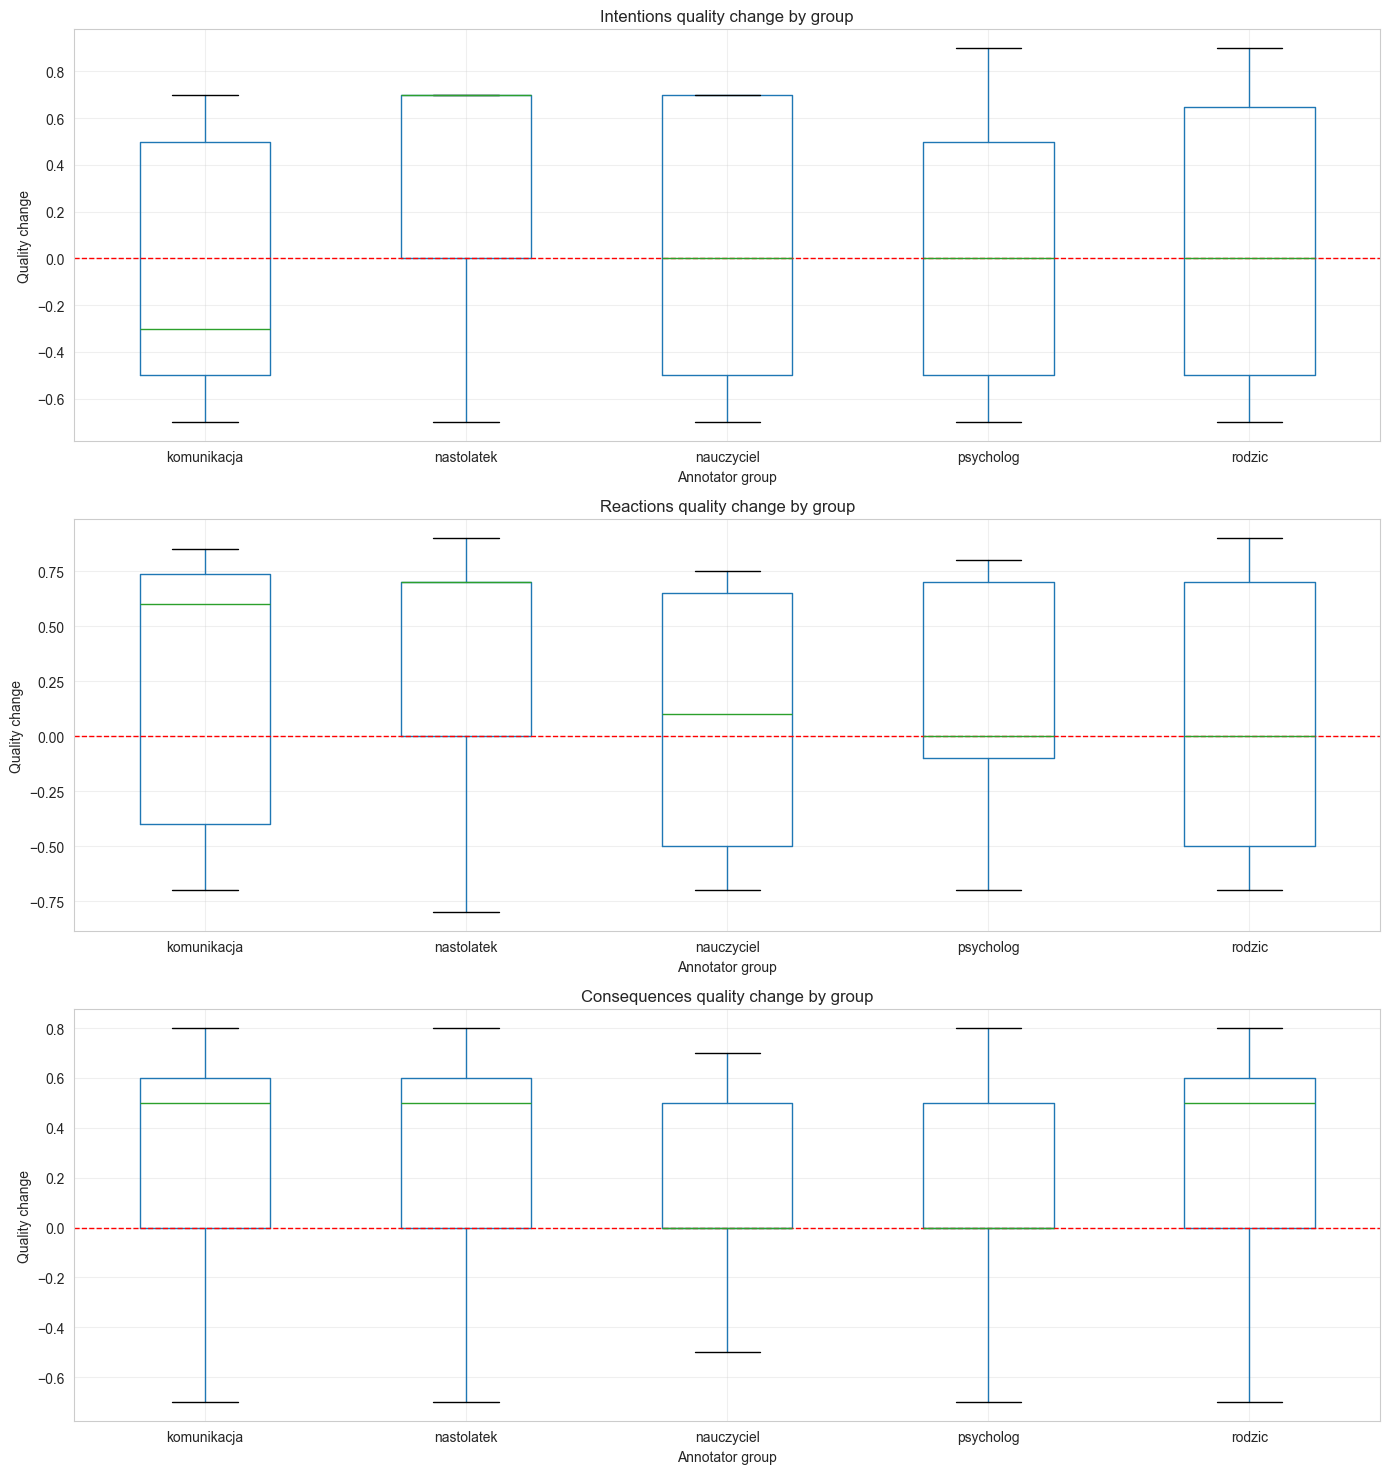

In [35]:
fig, axes = plt.subplots(3, 1, figsize=(14, 15))

# Intentions
intentions_df.boxplot(column='intention_evolution_assessment_quality_change', by='annotator_group', ax=axes[0])
axes[0].set_xlabel('Annotator group')
axes[0].set_ylabel('Quality change')
axes[0].set_title('Intentions quality change by group')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].grid(alpha=0.3)

# Reactions
reactions_df.boxplot(column='reaction_evolution_assessment_quality_change', by='annotator_group', ax=axes[1])
axes[1].set_xlabel('Annotator group')
axes[1].set_ylabel('Quality change')
axes[1].set_title('Reactions quality change by group')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].grid(alpha=0.3)

# Consequences
consequences_df.boxplot(column='consequences_evolution_assessment_quality_change', by='annotator_group', ax=axes[2])
axes[2].set_xlabel('Annotator group')
axes[2].set_ylabel('Quality change')
axes[2].set_title('Consequences quality change by group')
axes[2].axhline(0, color='red', linestyle='--', linewidth=1)
axes[2].grid(alpha=0.3)

plt.suptitle('')
plt.tight_layout()
plt.show()

### 6.3 Evolution types

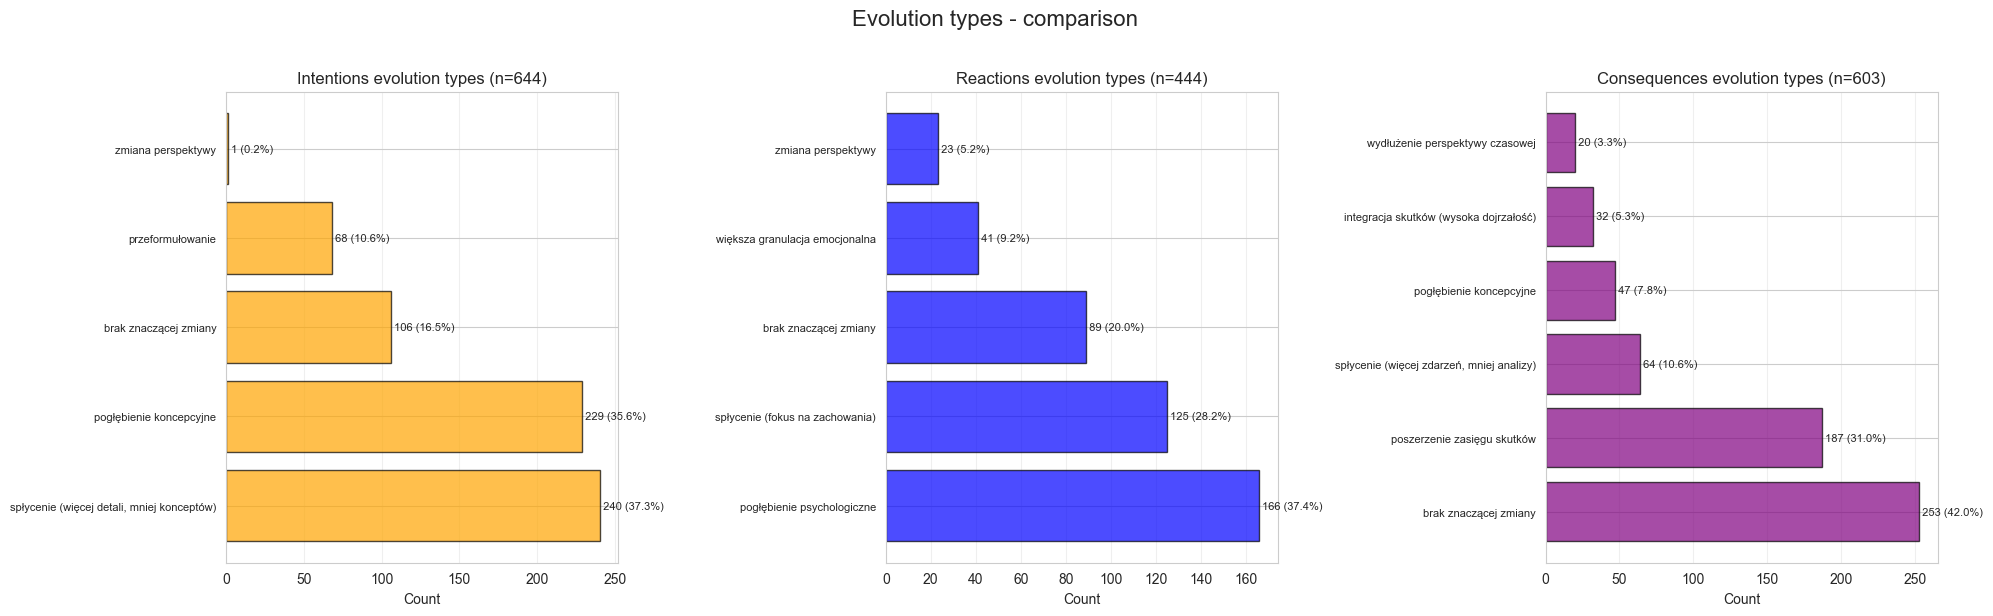

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Intentions
intention_types = intentions_df['intention_evolution_assessment_type'].value_counts()
axes[0].barh(range(len(intention_types)), intention_types.values, edgecolor='black', alpha=0.7, color='orange')
axes[0].set_yticks(range(len(intention_types)))
axes[0].set_yticklabels(intention_types.index, fontsize=8)
axes[0].set_xlabel('Count')
axes[0].set_title(f'Intentions evolution types (n={len(intentions_df)})')
axes[0].grid(alpha=0.3, axis='x')
for i, val in enumerate(intention_types.values):
    axes[0].text(val, i, f' {val} ({val/len(intentions_df)*100:.1f}%)', va='center', fontsize=8)

# Reactions
reaction_types = reactions_df['reaction_evolution_assessment_type'].value_counts()
axes[1].barh(range(len(reaction_types)), reaction_types.values, edgecolor='black', alpha=0.7, color='blue')
axes[1].set_yticks(range(len(reaction_types)))
axes[1].set_yticklabels(reaction_types.index, fontsize=8)
axes[1].set_xlabel('Count')
axes[1].set_title(f'Reactions evolution types (n={len(reactions_df)})')
axes[1].grid(alpha=0.3, axis='x')
for i, val in enumerate(reaction_types.values):
    axes[1].text(val, i, f' {val} ({val/len(reactions_df)*100:.1f}%)', va='center', fontsize=8)

# Consequences
consequences_types = consequences_df['consequences_evolution_assessment_type'].value_counts()
axes[2].barh(range(len(consequences_types)), consequences_types.values, edgecolor='black', alpha=0.7, color='purple')
axes[2].set_yticks(range(len(consequences_types)))
axes[2].set_yticklabels(consequences_types.index, fontsize=8)
axes[2].set_xlabel('Count')
axes[2].set_title(f'Consequences evolution types (n={len(consequences_df)})')
axes[2].grid(alpha=0.3, axis='x')
for i, val in enumerate(consequences_types.values):
    axes[2].text(val, i, f' {val} ({val/len(consequences_df)*100:.1f}%)', va='center', fontsize=8)

plt.suptitle('Evolution types - comparison', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### 6.4 Correlations 

Rows with complete data for all three types: 423 (56.4% of total)


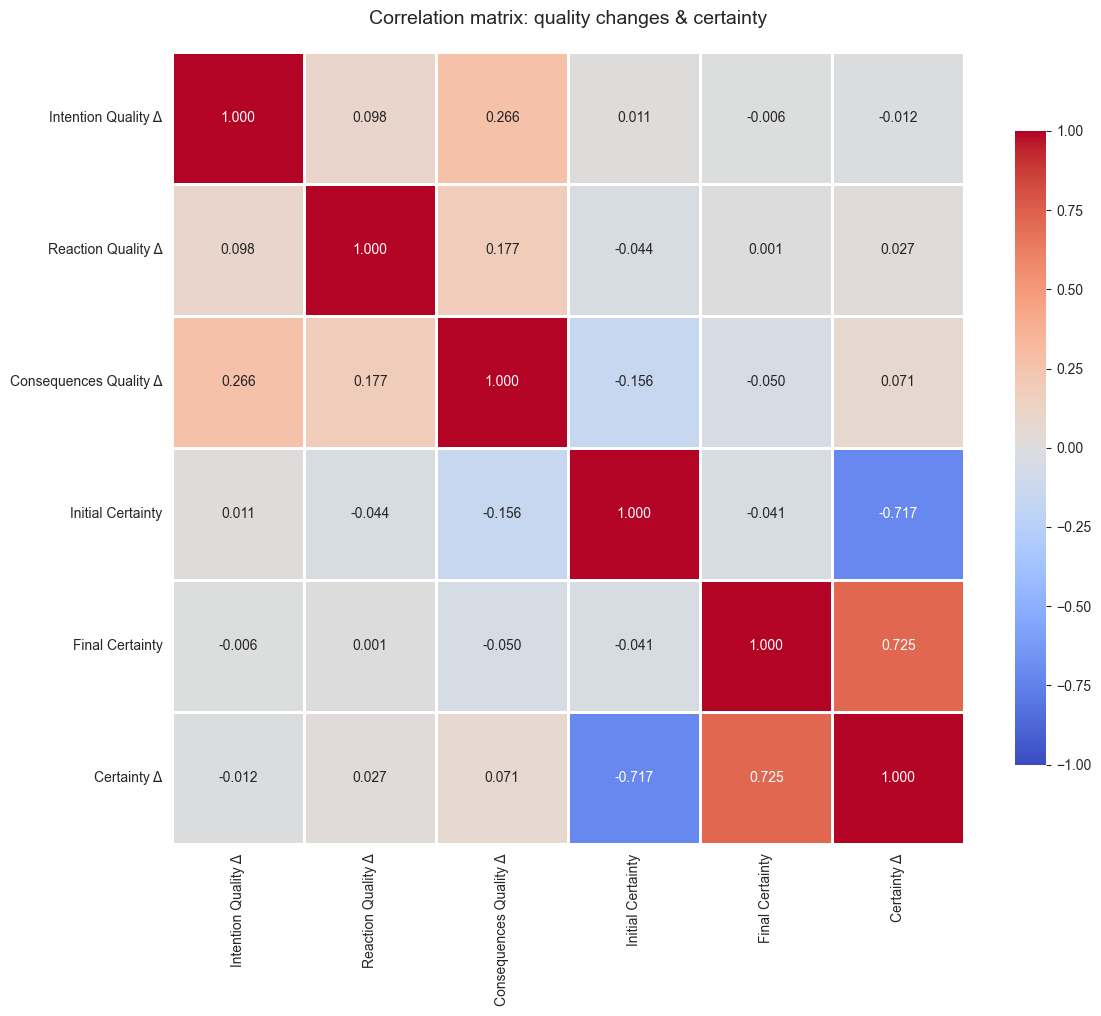


Key correlations:

Quality changes:
  Intention vs Reaction: 0.098
  Intention vs Consequences: 0.266
  Reaction vs Consequences: 0.177

Certainty vs Quality changes:
  Certainty Δ vs Intention Quality Δ: -0.012
  Certainty Δ vs Reaction Quality Δ: 0.027
  Certainty Δ vs Consequences Quality Δ: 0.071

Initial Certainty vs Quality changes:
  Initial Certainty vs Intention Quality Δ: 0.011
  Initial Certainty vs Reaction Quality Δ: -0.044
  Initial Certainty vs Consequences Quality Δ: -0.156


In [42]:
# Create a merged dataset for correlation analysis
# Note: This will only include rows that have complete data for all three types
complete_data = df[
    (df['first_question_4_intention'].notna() & (df['first_question_4_intention'] != '') & 
     df['repeated_question_4_intention'].notna() & (df['repeated_question_4_intention'] != '')) &
    (df['first_question_9_reaction'].notna() & (df['first_question_9_reaction'] != '') & 
     df['repeated_question_9_reaction'].notna() & (df['repeated_question_9_reaction'] != '')) &
    (df['first_question_5_consequences'].notna() & (df['first_question_5_consequences'] != '') & 
     df['repeated_question_5_consequences'].notna() & (df['repeated_question_5_consequences'] != ''))
].copy()

print(f"Rows with complete data for all three types: {len(complete_data)} ({len(complete_data)/len(df)*100:.1f}% of total)")

correlation_cols = [
    'intention_evolution_assessment_quality_change',
    'reaction_evolution_assessment_quality_change',
    'consequences_evolution_assessment_quality_change',
    'first_question_10_certainty',
    'repeated_question_10_certainty',
    'certainty_change'
]

col_labels = {
    'intention_evolution_assessment_quality_change': 'Intention Quality Δ',
    'reaction_evolution_assessment_quality_change': 'Reaction Quality Δ',
    'consequences_evolution_assessment_quality_change': 'Consequences Quality Δ',
    'first_question_10_certainty': 'Initial Certainty',
    'repeated_question_10_certainty': 'Final Certainty',
    'certainty_change': 'Certainty Δ'
}

corr_data = complete_data[correlation_cols].copy()
corr_data.columns = [col_labels[col] for col in correlation_cols]
corr_matrix = corr_data.corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation matrix: quality changes & certainty', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

print("\nKey correlations:")
print(f"\nQuality changes:")
print(f"  Intention vs Reaction: {corr_matrix.loc['Intention Quality Δ', 'Reaction Quality Δ']:.3f}")
print(f"  Intention vs Consequences: {corr_matrix.loc['Intention Quality Δ', 'Consequences Quality Δ']:.3f}")
print(f"  Reaction vs Consequences: {corr_matrix.loc['Reaction Quality Δ', 'Consequences Quality Δ']:.3f}")

print(f"\nCertainty vs Quality changes:")
print(f"  Certainty Δ vs Intention Quality Δ: {corr_matrix.loc['Certainty Δ', 'Intention Quality Δ']:.3f}")
print(f"  Certainty Δ vs Reaction Quality Δ: {corr_matrix.loc['Certainty Δ', 'Reaction Quality Δ']:.3f}")
print(f"  Certainty Δ vs Consequences Quality Δ: {corr_matrix.loc['Certainty Δ', 'Consequences Quality Δ']:.3f}")

print(f"\nInitial Certainty vs Quality changes:")
print(f"  Initial Certainty vs Intention Quality Δ: {corr_matrix.loc['Initial Certainty', 'Intention Quality Δ']:.3f}")
print(f"  Initial Certainty vs Reaction Quality Δ: {corr_matrix.loc['Initial Certainty', 'Reaction Quality Δ']:.3f}")
print(f"  Initial Certainty vs Consequences Quality Δ: {corr_matrix.loc['Initial Certainty', 'Consequences Quality Δ']:.3f}")

### 6.5 Answer length 

Does writing longer answers correlate with quality improvement? 

In [45]:
# Calculate answer lengths for intentions
intentions_df['intention_length_before'] = intentions_df['first_question_4_intention'].fillna('').astype(str).str.len()
intentions_df['intention_length_after'] = intentions_df['repeated_question_4_intention'].fillna('').astype(str).str.len()
intentions_df['intention_length_change'] = intentions_df['intention_length_after'] - intentions_df['intention_length_before']
intentions_df['intention_length_change_pct'] = (intentions_df['intention_length_change'] / intentions_df['intention_length_before'].replace(0, 1)) * 100

# Calculate answer lengths for reactions
reactions_df['reaction_length_before'] = reactions_df['first_question_9_reaction'].fillna('').astype(str).str.len()
reactions_df['reaction_length_after'] = reactions_df['repeated_question_9_reaction'].fillna('').astype(str).str.len()
reactions_df['reaction_length_change'] = reactions_df['reaction_length_after'] - reactions_df['reaction_length_before']
reactions_df['reaction_length_change_pct'] = (reactions_df['reaction_length_change'] / reactions_df['reaction_length_before'].replace(0, 1)) * 100

# Calculate answer lengths for consequences
consequences_df['consequences_length_before'] = consequences_df['first_question_5_consequences'].fillna('').astype(str).str.len()
consequences_df['consequences_length_after'] = consequences_df['repeated_question_5_consequences'].fillna('').astype(str).str.len()
consequences_df['consequences_length_change'] = consequences_df['consequences_length_after'] - consequences_df['consequences_length_before']
consequences_df['consequences_length_change_pct'] = (consequences_df['consequences_length_change'] / consequences_df['consequences_length_before'].replace(0, 1)) * 100

print("="*80)
print("ANSWER LENGTH STATISTICS")
print("="*80)

for name, df_subset, prefix in [('Intentions', intentions_df, 'intention'),
                                  ('Reactions', reactions_df, 'reaction'),
                                  ('Consequences', consequences_df, 'consequences')]:
    print(f"\n{name}:")
    print(f"  Before: Mean={df_subset[f'{prefix}_length_before'].mean():.1f} chars, Median={df_subset[f'{prefix}_length_before'].median():.0f}")
    print(f"  After:  Mean={df_subset[f'{prefix}_length_after'].mean():.1f} chars, Median={df_subset[f'{prefix}_length_after'].median():.0f}")
    print(f"  Change: Mean={df_subset[f'{prefix}_length_change'].mean():.1f} chars ({df_subset[f'{prefix}_length_change_pct'].mean():.1f}%)")
    
    increased = (df_subset[f'{prefix}_length_change'] > 0).sum()
    decreased = (df_subset[f'{prefix}_length_change'] < 0).sum()
    same = (df_subset[f'{prefix}_length_change'] == 0).sum()
    
    print(f"  Increased: {increased} ({increased/len(df_subset)*100:.1f}%)")
    print(f"  Decreased: {decreased} ({decreased/len(df_subset)*100:.1f}%)")
    print(f"  Same: {same} ({same/len(df_subset)*100:.1f}%)")

print("="*80)

ANSWER LENGTH STATISTICS

Intentions:
  Before: Mean=84.7 chars, Median=74
  After:  Mean=104.4 chars, Median=90
  Change: Mean=19.7 chars (80.0%)
  Increased: 394 (61.2%)
  Decreased: 248 (38.5%)
  Same: 2 (0.3%)

Reactions:
  Before: Mean=78.5 chars, Median=69
  After:  Mean=100.1 chars, Median=84
  Change: Mean=21.6 chars (92.9%)
  Increased: 262 (59.0%)
  Decreased: 178 (40.1%)
  Same: 4 (0.9%)

Consequences:
  Before: Mean=113.8 chars, Median=89
  After:  Mean=127.2 chars, Median=107
  Change: Mean=13.4 chars (105.3%)
  Increased: 326 (54.1%)
  Decreased: 272 (45.1%)
  Same: 5 (0.8%)


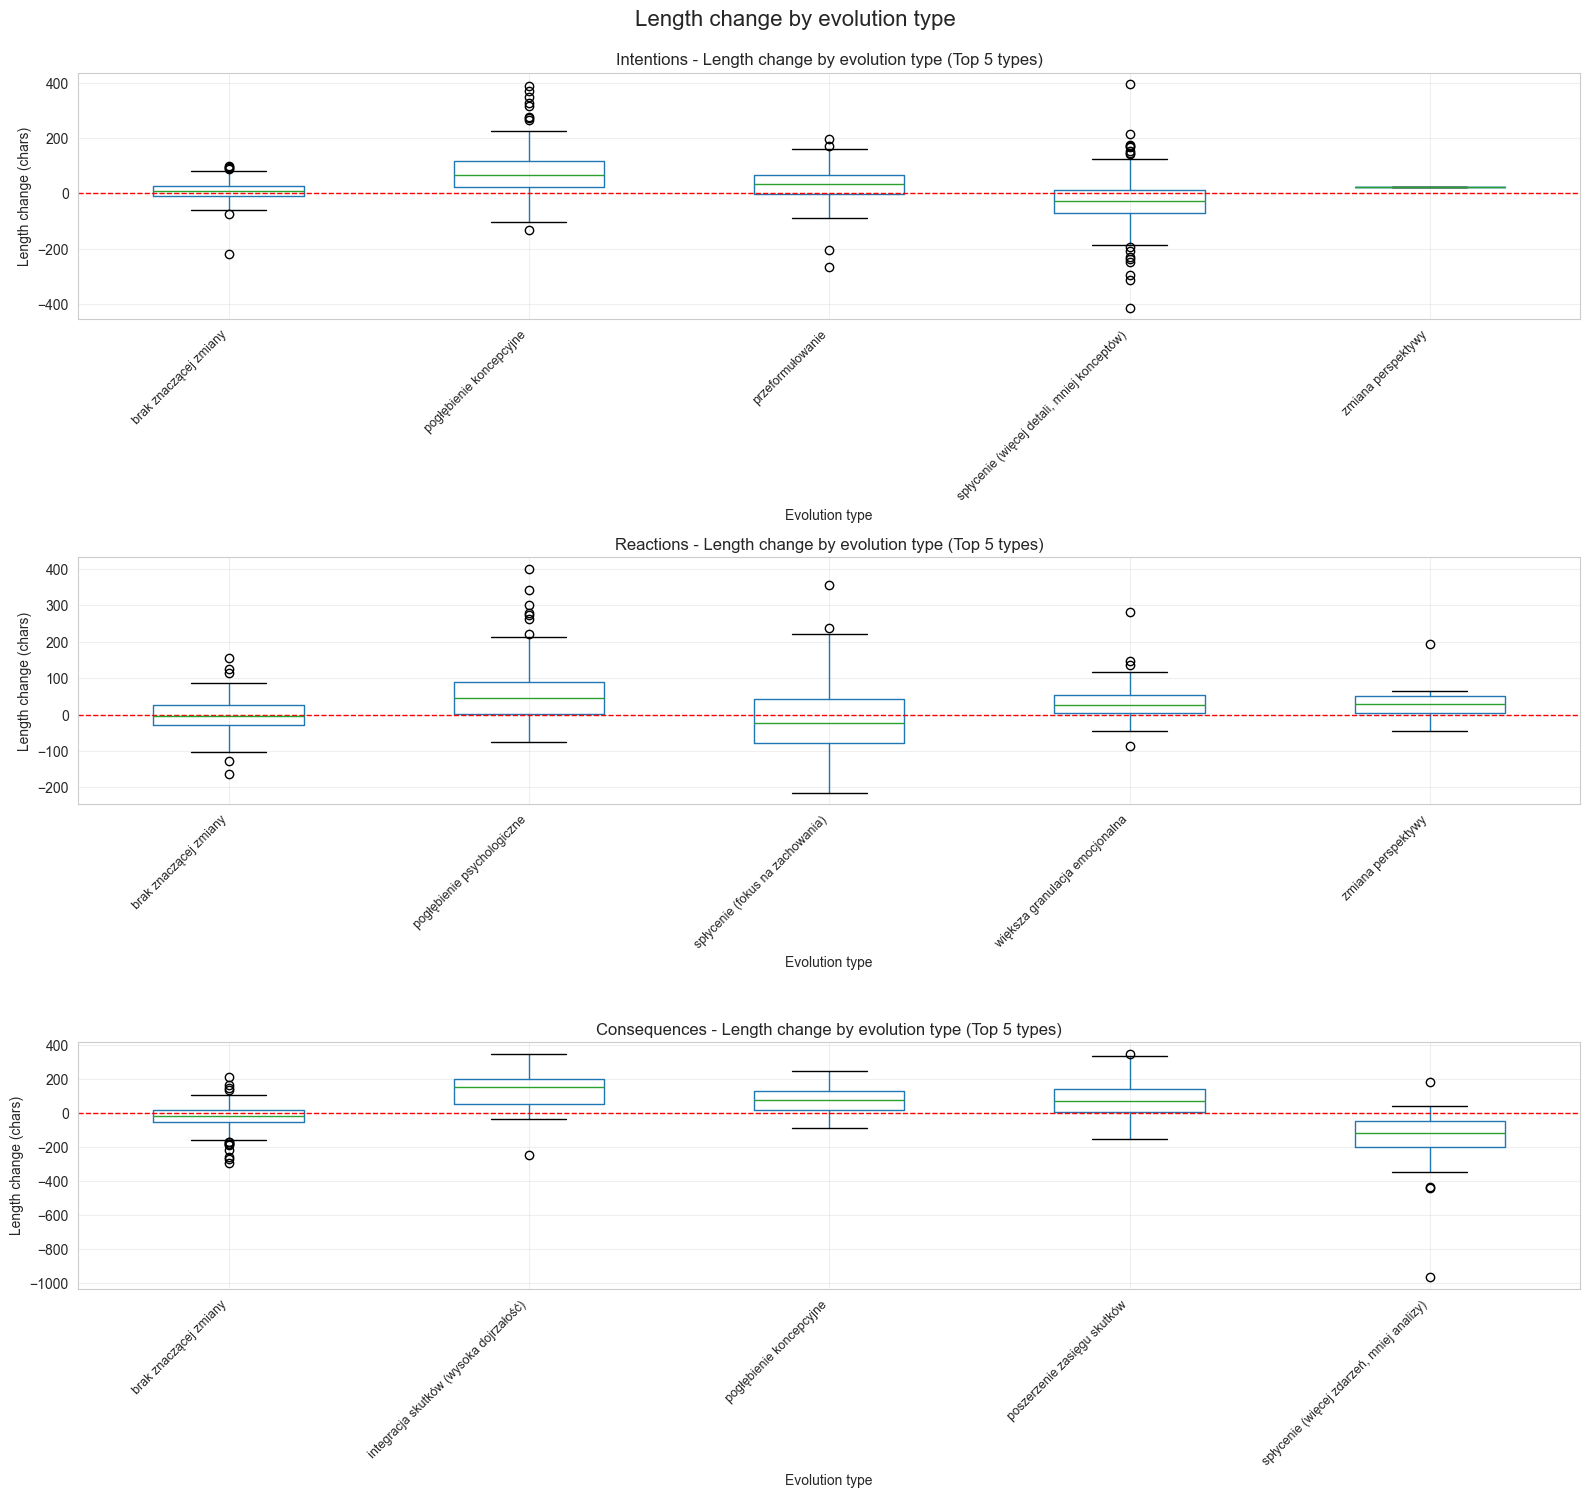

In [46]:
# Visualize length change by evolution type (top 5 types for each)
fig, axes = plt.subplots(3, 1, figsize=(16, 15))

for idx, (name, df_subset, prefix, color) in enumerate([
    ('Intentions', intentions_df, 'intention', 'orange'),
    ('Reactions', reactions_df, 'reaction', 'blue'),
    ('Consequences', consequences_df, 'consequences', 'purple')
]):
    # Get top 5 most common evolution types
    top_types = df_subset[f'{prefix}_evolution_assessment_type'].value_counts().head(5).index
    filtered_data = df_subset[df_subset[f'{prefix}_evolution_assessment_type'].isin(top_types)]
    
    # Create boxplot
    filtered_data.boxplot(column=f'{prefix}_length_change', 
                          by=f'{prefix}_evolution_assessment_type', 
                          ax=axes[idx])
    axes[idx].set_xlabel('Evolution type')
    axes[idx].set_ylabel('Length change (chars)')
    axes[idx].set_title(f'{name} - Length change by evolution type (Top 5 types)')
    axes[idx].axhline(0, color='red', linestyle='--', linewidth=1)
    axes[idx].grid(alpha=0.3)
    
    # Rotate labels 
    axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=45, ha='right', fontsize=9)

plt.suptitle('Length change by evolution type', fontsize=16, y=0.995)
plt.tight_layout()
plt.show()

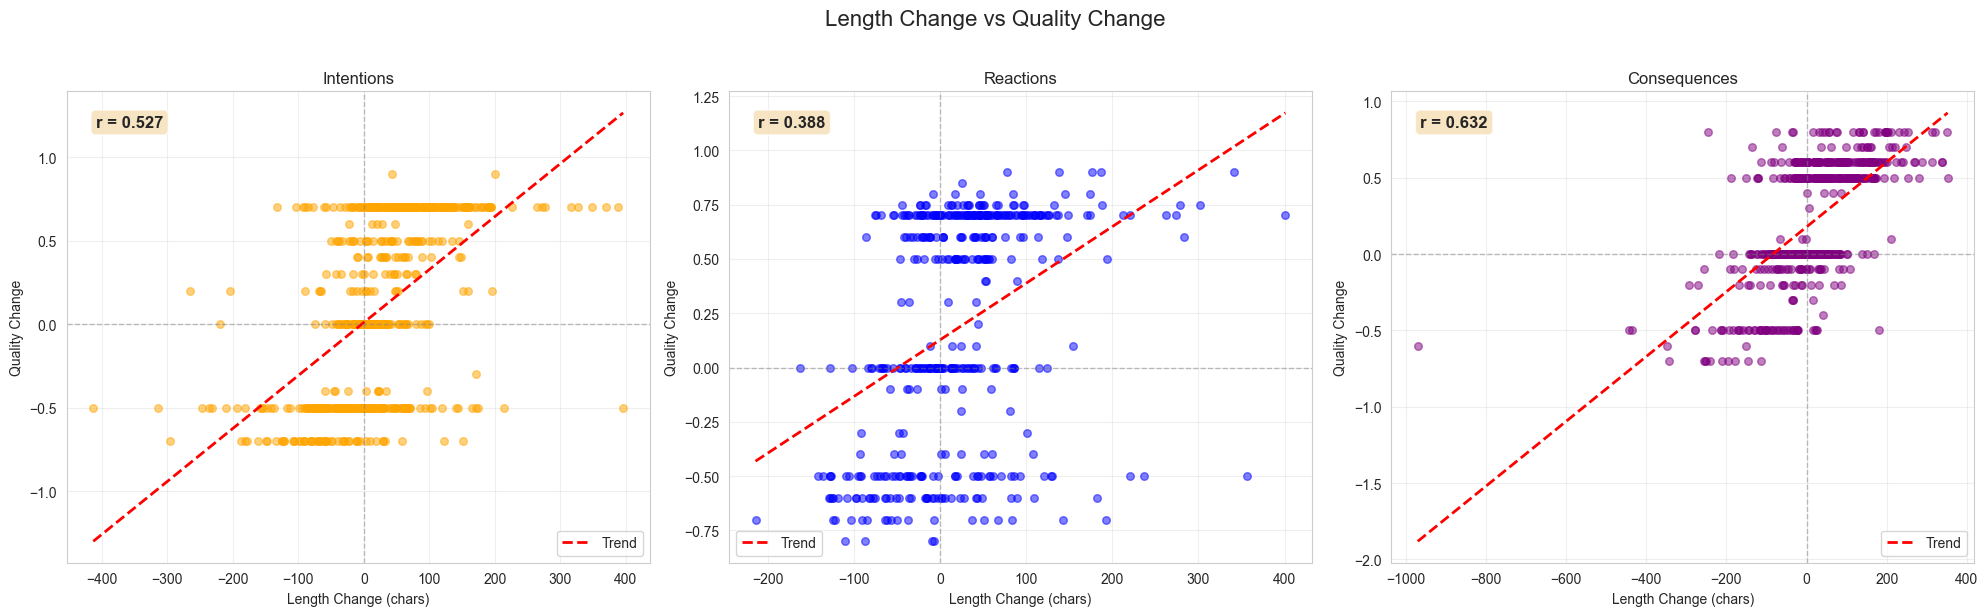

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, (name, df_subset, prefix, color) in enumerate([
    ('Intentions', intentions_df, 'intention', 'orange'),
    ('Reactions', reactions_df, 'reaction', 'blue'),
    ('Consequences', consequences_df, 'consequences', 'purple')
]):
    # Scatter plot with trend line
    axes[idx].scatter(df_subset[f'{prefix}_length_change'], 
                     df_subset[f'{prefix}_evolution_assessment_quality_change'],
                     alpha=0.5, s=30, color=color)
    
    # Add trend line
    z = np.polyfit(df_subset[f'{prefix}_length_change'].fillna(0), 
                   df_subset[f'{prefix}_evolution_assessment_quality_change'].fillna(0), 1)
    p = np.poly1d(z)
    x_trend = np.linspace(df_subset[f'{prefix}_length_change'].min(), 
                          df_subset[f'{prefix}_length_change'].max(), 100)
    axes[idx].plot(x_trend, p(x_trend), "r--", linewidth=2, label='Trend')
    
    # Add reference lines
    axes[idx].axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    axes[idx].axvline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    
    axes[idx].set_xlabel('Length Change (chars)')
    axes[idx].set_ylabel('Quality Change')
    axes[idx].set_title(f'{name}')
    axes[idx].grid(alpha=0.3)
    axes[idx].legend()
    
    # Add correlation text
    corr = df_subset[[f'{prefix}_length_change', f'{prefix}_evolution_assessment_quality_change']].corr().iloc[0, 1]
    axes[idx].text(0.05, 0.95, f'r = {corr:.3f}', transform=axes[idx].transAxes,
                   verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
                   fontsize=12, fontweight='bold')

plt.suptitle('Length change vs quality change', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [49]:
print("="*80)
print("CORRELATION: LENGTH CHANGE vs QUALITY CHANGE")
print("="*80)

for name, df_subset, prefix in [
    ('Intentions', intentions_df, 'intention'),
    ('Reactions', reactions_df, 'reaction'),
    ('Consequences', consequences_df, 'consequences')
]:
    corr = df_subset[[f'{prefix}_length_change', f'{prefix}_evolution_assessment_quality_change']].corr().iloc[0, 1]
    print(f"\n{name}:")
    print(f"  Correlation (length Δ vs quality Δ): {corr:.3f}")
    
    # By annotator group
    print(f"  By annotator group:")
    for group in sorted(df_subset['annotator_group'].unique()):
        group_data = df_subset[df_subset['annotator_group'] == group]
        if len(group_data) > 2:  # Need at least 3 points for correlation
            group_corr = group_data[[f'{prefix}_length_change', f'{prefix}_evolution_assessment_quality_change']].corr().iloc[0, 1]
            print(f"    {group:15s}: {group_corr:6.3f} (n={len(group_data)})")

print("="*80)

CORRELATION: LENGTH CHANGE vs QUALITY CHANGE

Intentions:
  Correlation (length Δ vs quality Δ): 0.527
  By annotator group:
    komunikacja    :  0.676 (n=127)
    nastolatek     :  0.421 (n=127)
    nauczyciel     :  0.562 (n=132)
    psycholog      :  0.437 (n=127)
    rodzic         :  0.515 (n=131)

Reactions:
  Correlation (length Δ vs quality Δ): 0.388
  By annotator group:
    komunikacja    :  0.426 (n=78)
    nastolatek     :  0.266 (n=81)
    nauczyciel     :  0.331 (n=103)
    psycholog      :  0.666 (n=97)
    rodzic         :  0.416 (n=85)

Consequences:
  Correlation (length Δ vs quality Δ): 0.632
  By annotator group:
    komunikacja    :  0.653 (n=114)
    nastolatek     :  0.614 (n=117)
    nauczyciel     :  0.488 (n=126)
    psycholog      :  0.658 (n=120)
    rodzic         :  0.667 (n=126)


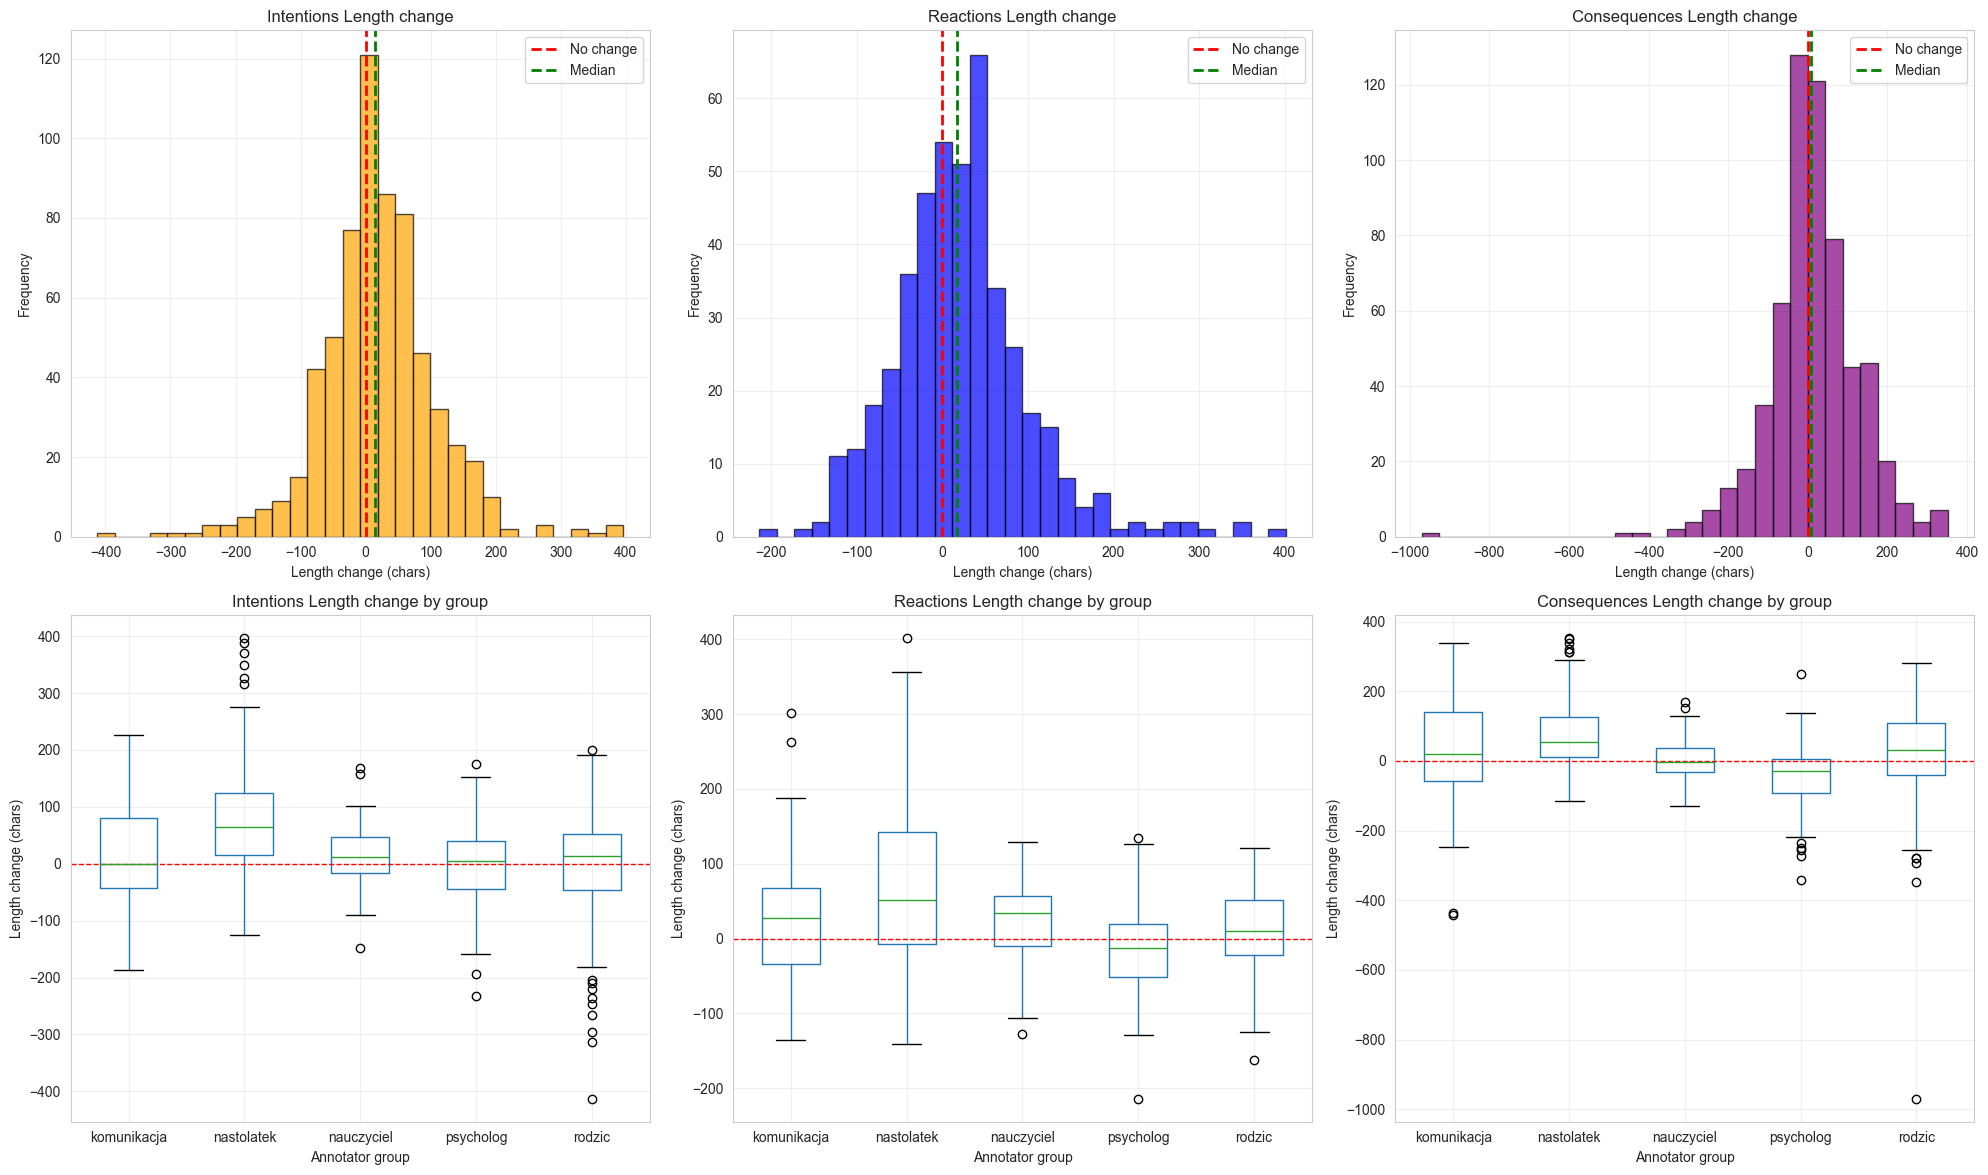

In [51]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

for idx, (name, df_subset, prefix, color) in enumerate([
    ('Intentions', intentions_df, 'intention', 'orange'),
    ('Reactions', reactions_df, 'reaction', 'blue'),
    ('Consequences', consequences_df, 'consequences', 'purple')
]):
    axes[0, idx].hist(df_subset[f'{prefix}_length_change'], bins=30, edgecolor='black', alpha=0.7, color=color)
    axes[0, idx].axvline(0, color='red', linestyle='--', linewidth=2, label='No change')
    axes[0, idx].axvline(df_subset[f'{prefix}_length_change'].median(), color='green', linestyle='--', linewidth=2, label='Median')
    axes[0, idx].set_xlabel('Length change (chars)')
    axes[0, idx].set_ylabel('Frequency')
    axes[0, idx].set_title(f'{name} Length change')
    axes[0, idx].legend()
    axes[0, idx].grid(alpha=0.3)

# Row 2: Length change by annotator group
for idx, (name, df_subset, prefix) in enumerate([
    ('Intentions', intentions_df, 'intention'),
    ('Reactions', reactions_df, 'reaction'),
    ('Consequences', consequences_df, 'consequences')
]):
    df_subset.boxplot(column=f'{prefix}_length_change', by='annotator_group', ax=axes[1, idx])
    axes[1, idx].set_xlabel('Annotator group')
    axes[1, idx].set_ylabel('Length change (chars)')
    axes[1, idx].set_title(f'{name} Length change by group')
    axes[1, idx].axhline(0, color='red', linestyle='--', linewidth=1)
    axes[1, idx].grid(alpha=0.3)

plt.suptitle('')
plt.tight_layout()
plt.show()

### 6.5 Summary

In [61]:
print("\n" + "="*80)
print("SUMMARY")
print("="*80)

print(f"\nTotal dataset: {len(df)} rows")
print(f"\nFiltered datasets:")
print(f"  Intentions: {len(intentions_df)} rows ({len(intentions_df)/len(df)*100:.1f}%)")
print(f"  Reactions: {len(reactions_df)} rows ({len(reactions_df)/len(df)*100:.1f}%)")
print(f"  Consequences: {len(consequences_df)} rows ({len(consequences_df)/len(df)*100:.1f}%)")
print(f"  Complete (all three): {len(complete_data)} rows ({len(complete_data)/len(df)*100:.1f}%)")

print(f"\nQuality change summary:")
print(f"  Intentions: Mean={intentions_df['intention_evolution_assessment_quality_change'].mean():.3f}, Improvement={(intentions_df['intention_evolution_assessment_quality_change'] > 0).mean():.1%}")
print(f"  Reactions: Mean={reactions_df['reaction_evolution_assessment_quality_change'].mean():.3f}, Improvement={(reactions_df['reaction_evolution_assessment_quality_change'] > 0).mean():.1%}")
print(f"  Consequences: Mean={consequences_df['consequences_evolution_assessment_quality_change'].mean():.3f}, Improvement={(consequences_df['consequences_evolution_assessment_quality_change'] > 0).mean():.1%}")

print(f"\nAnswer length changes:")
print(f"  Intentions: Mean={intentions_df['intention_length_change'].mean():.1f} chars (+{intentions_df['intention_length_change_pct'].mean():.0f}%), Increased={(intentions_df['intention_length_change'] > 0).mean():.1%}")
print(f"  Reactions: Mean={reactions_df['reaction_length_change'].mean():.1f} chars (+{reactions_df['reaction_length_change_pct'].mean():.0f}%), Increased={(reactions_df['reaction_length_change'] > 0).mean():.1%}")
print(f"  Consequences: Mean={consequences_df['consequences_length_change'].mean():.1f} chars (+{consequences_df['consequences_length_change_pct'].mean():.0f}%), Increased={(consequences_df['consequences_length_change'] > 0).mean():.1%}")

print(f"\nLength-Quality correlations:")
intentions_corr = intentions_df[['intention_length_change', 'intention_evolution_assessment_quality_change']].corr().iloc[0, 1]
reactions_corr = reactions_df[['reaction_length_change', 'reaction_evolution_assessment_quality_change']].corr().iloc[0, 1]
consequences_corr = consequences_df[['consequences_length_change', 'consequences_evolution_assessment_quality_change']].corr().iloc[0, 1]
print(f"  Intentions: r={intentions_corr:.3f} (moderate positive)")
print(f"  Reactions: r={reactions_corr:.3f} (weak-moderate positive)")
print(f"  Consequences: r={consequences_corr:.3f} (stronger positive)")

print(f"\nSemantic similarity summary:")
print(f"  Intentions: Mean={intentions_df['intention_semantic_similarity'].mean():.3f}")
print(f"  Reactions: Mean={reactions_df['reaction_semantic_similarity'].mean():.3f}")
print(f"  Consequences: Mean={consequences_df['consequences_semantic_similarity'].mean():.3f}")

print(f"\n" + "="*80)
print("KEY FINDINGS")
print("="*80)

# Find which type has highest quality improvement
quality_means = {
    'Intentions': intentions_df['intention_evolution_assessment_quality_change'].mean(),
    'Reactions': reactions_df['reaction_evolution_assessment_quality_change'].mean(),
    'Consequences': consequences_df['consequences_evolution_assessment_quality_change'].mean()
}
best_quality = max(quality_means, key=quality_means.get)

# Find which type has highest semantic similarity
similarity_means = {
    'Intentions': intentions_df['intention_semantic_similarity'].mean(),
    'Reactions': reactions_df['reaction_semantic_similarity'].mean(),
    'Consequences': consequences_df['consequences_semantic_similarity'].mean()
}
best_consistency = max(similarity_means, key=similarity_means.get)

# Find which type has strongest length-quality correlation
length_corrs = {
    'Intentions': intentions_corr,
    'Reactions': reactions_corr,
    'Consequences': consequences_corr
}
strongest_length_corr = max(length_corrs, key=length_corrs.get)

print(f"\n1. QUALITY IMPROVEMENT")
print(f"   → {best_quality} showed the highest mean quality improvement ({quality_means[best_quality]:.3f})")
print(f"   → Improvement rates: Reactions 53.2% > Consequences 48.1% > Intentions 46.0%")

print(f"\n2. CONSISTENCY")
print(f"   → {best_consistency} showed the highest semantic similarity ({similarity_means[best_consistency]:.3f})")
print(f"   → This indicates most consistent annotations between first and repeated attempts")

print(f"\n3. CERTAINTY")
print(f"   → Overall certainty increased: Mean Δ={df['certainty_change'].mean():.3f}, {(df['certainty_change'] > 0).mean():.1%} improved")
print(f"   → Annotators became more confident in their judgments over time")

print(f"\n4. ANSWER LENGTH & QUALITY CORRELATION")
print(f"   → {strongest_length_corr} shows strongest correlation (r={length_corrs[strongest_length_corr]:.3f})")
print(f"   → ALL three types show POSITIVE correlations:")
print(f"     • Intentions: r={intentions_corr:.3f} - moderate positive relationship")
print(f"     • Reactions: r={reactions_corr:.3f} - weak-moderate positive relationship")  
print(f"     • Consequences: r={consequences_corr:.3f} - stronger positive relationship")
print(f"   → This suggests: LONGER answers tend to be BETTER quality")
print(f"   → On average, answers increased by ~15-20 chars, with 54-61% getting longer")

print(f"\n5. LENGTH CHANGES MATCH EVOLUTION TYPES INTUITIVELY")
print(f"   → Evolution types that typically INCREASE length:")
print(f"     • 'pogłębienie koncepcyjne/psychologiczne'")
print(f"     • 'poszerzenie zasięgu skutków'")
print(f"     • 'większa granulacja emocjonalna'")
print(f"     • 'wydłużenie perspektywy czasowej'")
print(f"     • 'integracja skutków'")
print(f"   → Evolution types that MAINTAIN or REDUCE length:")
print(f"     • 'przeformułowanie'")
print(f"     • 'zmiana perspektywy'")
print(f"     • 'spłycenie' (shallowing) → less analysis, more surface details")
print(f"   → This validates that length changes align meaningfully with evolution semantics")
print(f"   → Types that add depth, scope, or granularity naturally require more words")


SUMMARY

Total dataset: 750 rows

Filtered datasets:
  Intentions: 644 rows (85.9%)
  Reactions: 444 rows (59.2%)
  Consequences: 603 rows (80.4%)
  Complete (all three): 423 rows (56.4%)

Quality change summary:
  Intentions: Mean=0.072, Improvement=46.0%
  Reactions: Mean=0.183, Improvement=53.2%
  Consequences: Mean=0.206, Improvement=48.1%

Answer length changes:
  Intentions: Mean=19.7 chars (+80%), Increased=61.2%
  Reactions: Mean=21.6 chars (+93%), Increased=59.0%
  Consequences: Mean=13.4 chars (+105%), Increased=54.1%

Length-Quality correlations:
  Intentions: r=0.527 (moderate positive)
  Reactions: r=0.388 (weak-moderate positive)
  Consequences: r=0.632 (stronger positive)

Semantic similarity summary:
  Intentions: Mean=0.430
  Reactions: Mean=0.316
  Consequences: Mean=0.284

KEY FINDINGS

1. QUALITY IMPROVEMENT
   → Consequences showed the highest mean quality improvement (0.206)
   → Improvement rates: Reactions 53.2% > Consequences 48.1% > Intentions 46.0%

2. CONSI